# 預測目標

這個競賽的評分指標叫 **Modified Sharpe Ratio（調整後 Sharpe）**。  
它的目標不是只看「賺不賺」，而是要找一個策略：

1. **風險調整後表現要好**（Sharpe 高）  
2. **不能太莽撞**（波動度不能比市場高太多）  
3. **而且要「明顯打敗市場」**（如果長期輸市場，會被重罰）

---

## 一、每天你要交出的決策是什麼？：$p_t$

每天 $t$ 你要提交一個 **部位訊號** $p_t$，範圍被限制在 $[0,2]$。

直覺解釋（把錢分配在兩個地方）：

- $p_t = 0$：**100% 放在無風險利率**（像現金/短債）
- $p_t = 1$：**100% 放在市場**（跟著 S&P 500）
- $p_t = 2$：**200% 放在市場**（等於 2 倍曝險，類似加槓桿）

所以 $p_t$ 就是你每天「市場曝險的倍數」。  
（你不是在預測漲跌標籤，你是在決定今天要押多少。）

---

## 二、符號與名詞

對於每一天 $t$：

- $p_t$：你提交的部位訊號（0 到 2）
- $R_{m,t}$：市場的 forward return（題目給的 `forward_returns`）
- $R_{f,t}$：無風險利率（題目給的 `risk_free_rate`）
- $N$：總天數

---

## 三、評分怎麼算

### 1) 策略每日報酬 $R_{s,t}$

你的資金一部分進市場（比例 $p_t$），其餘留在無風險（比例 $1-p_t$）。

$$
R_{s,t} = p_t \cdot R_{m,t} + (1-p_t)\cdot R_{f,t}
$$

白話：  
「你押在市場的那一部分跟著市場漲跌，沒押的那一部分就吃無風險利率。」

---

### 2) 策略每日超額報酬 $R^{e}_{s,t}$

Sharpe 的精神是看「超過無風險的報酬」：

$$
R^{e}_{s,t} = R_{s,t} - R_{f,t}
$$

白話：  
「我比把錢放在無風險多賺多少？」

---

### 3) 幾何平均超額報酬 $\bar R^{e}_{s,g}$

這裡用幾何平均，是因為報酬是「連乘」累積的（今天賺完、明天再在新本金上賺）。

$$
\bar R^{e}_{s,g} = \left(\prod_{t=1}^{N}(1+R^{e}_{s,t})\right)^{1/N} - 1
$$

白話：  
「把每天的成長率連乘起來，再換算成平均每天大概成長多少。」

---

### 4) 策略波動度（標準差）$\sigma_s$

$$
\sigma_s = \mathrm{StDev}(R_{s,1},\ldots,R_{s,N})
$$

白話：  
「你的策略報酬忽高忽低的程度。越不穩定，風險越大。」

---

### 5) 年化 Sharpe $S$

把「平均超額報酬」除以「波動度」，再乘上 $\sqrt{252}$ 做年化（大約一年 252 個交易日）。

$$
S = \frac{\bar R^{e}_{s,g}}{\sigma_s}\cdot \sqrt{252}
$$

白話：  
「同樣風險下，誰能穩定賺比較多；同樣報酬下，誰比較穩。」

---

## 四、兩個懲罰項（Modified 的重點）

### 6) 波動度懲罰 $P_v$

先算年化波動度：

$$
V_s = \sigma_s\sqrt{252},\qquad
V_m = \mathrm{StDev}(R_{m,1},\ldots,R_{m,N})\sqrt{252}
$$

若你的策略年化波動度比市場高超過 20%，就開始被罰：

$$
P_v = 1 + \max\left(0,\frac{V_s}{V_m}-1.2\right)
$$

白話：  
「你可以比市場更敢押，但不能比市場波動大太多；超過就扣分。」

---

### 7) 落後市場懲罰 $P_r$（非常重！）

先算市場的幾何平均超額報酬 $\bar R^{e}_{m,g}$（同樣的做法，只是把 $R_{m,t}-R_{f,t}$ 代入）。

接著算「年化的落後幅度」：

$$
G_r = \max\left(0,(\bar R^{e}_{m,g}-\bar R^{e}_{s,g})\cdot 252\right)
$$

最後用二次函數重罰：

$$
P_r = 1 + \frac{G_r^2}{100}
$$

白話：  
「如果你長期輸市場，不是小扣分，是用平方級數快速重罰。  
所以策略不能只是風險小、很穩，但一直賺輸市場。」

---

## 五、最後分數（Adjusted Sharpe）

$$
S_{\mathrm{adj}} = \frac{S}{P_v\cdot P_r}
$$

白話總結：  
- 先算你策略的 Sharpe（風險調整後表現）  
- 再看你是不是 **太衝（波動太大）**  
- 以及是不是 **打不贏市場（落後就重罰）**  
- 最後把 Sharpe 除以兩個懲罰，得到最終分數。

---

## 六、我們實際要提交什麼檔案？

你要交的是每一天的 $p_t$（0 到 2 之間）。  
在測試集 `test.csv` 裡通常會有 `is_scored`：

- `is_scored = True`：這天會被拿去算分數，你需要對這些天輸出 $p_t$
- `is_scored = False`：多半是提供「上下文」讓你做時間序推論（你可以用來更新歷史，但不一定會計分）

最終提交檔的欄位名稱請以 `sample_submission` 為準，但概念上就是：  
**對每個要計分的日期，交出一個 $p_t$。**

---

## 七、舉例

假設你的模型輸出一個預測值 $\hat y_t$，下面方式轉成部位：

$$
p_t = \mathrm{clip}(1+\text{multiplier}\cdot \hat y_t,\,0,\,2)
$$

白話：  
- $\hat y_t > 0$：多押市場，$p_t$ 往 2 靠  
- $\hat y_t < 0$：少押市場，$p_t$ 往 0 靠  
- `clip`：確保不會超過 0～2

---

## 八、補充

$$\bar R^{e}_{m,g}$$ 代表「**市場的幾何平均超額報酬**」。

- 「市場」指的是題目給的市場 forward return：`forward_returns`  
- 「超額」指的是扣掉無風險利率：`risk_free_rate`  
- 「幾何平均」是因為報酬是用連乘方式累積（比較符合長期複利）

### 1) 市場每日超額報酬
$$
R^{e}_{m,t} = R_{m,t} - R_{f,t}
$$

白話：  
「如果我每天都100%買市場，跟放無風險相比，我每天多賺/少賺多少。」

### 2) 市場幾何平均超額報酬
$$
\bar R^{e}_{m,g} = \left(\prod_{t=1}^{N} (1+R^{e}_{m,t})\right)^{1/N} - 1
$$

白話：  
「把市場每天的超額報酬做複利連乘，換算成平均每天的超額成長率。」


---
## 九、我們的建模目標：用特徵預測 $y_t$，再把 $\hat y_t$ 轉成要提交的 $p_t$

### 9.1 把 $y_t$ 定義為 `market_forward_excess_returns`

在 train 資料中，官方提供了一個欄位：

- `market_forward_excess_returns`

我們把它直接當作每天的目標變數：

$$
y_t \equiv \text{market_forward_excess_returns}_t
$$

白話：  
這個 $y_t$ 可以理解成「**市場明天的報酬，先扣掉長期（五年）平均的預期水準，再把極端值用 winsorize 壓掉後的結果**」。  
也就是一個比較「去趨勢、去極端值」的市場超額訊號，因此很多人會拿它當作比較乾淨、比較穩的預測目標。

---

### 9.2 模型會產生 $\hat y_t$，但我們最後要交的是 $p_t$

重點：**比賽不是要你提交 $y_t$ 或 $\hat y_t$，而是要你每天提交部位 $p_t$（介於 0 到 2）。**

- $p_t=0$：當天完全放在無風險利率（現金）
- $p_t=1$：當天 100% 跟著市場
- $p_t=2$：當天 200% 市場曝險（更激進）

因此，我們需要一個「從預測值 $\hat y_t$ 轉成部位 $p_t$」的規則。

---

### 9.3 設計一個把 $\hat y_t$ 轉成 $p_t$ 的函數（提交用）

常見又直覺的做法是：

1. 先用 $1+\text{multiplier}\cdot \hat y_t$ 把「沒訊號」對應到 $p_t=1$  
2. 再用 `clip` 把部位限制在 $[0,2]$，避免太極端

$$
p_t = \mathrm{clip}\!\left(1+\text{multiplier}\cdot \hat y_t,\;0,\;2\right)
$$

白話：  
- $\hat y_t$ 越大（越看好）→ $p_t$ 越接近 2（提高市場曝險）  
- $\hat y_t$ 越小或負（越不看好）→ $p_t$ 越接近 0（降低曝險、偏保守）  
- `multiplier` 控制「部位對預測值的敏感度」：越大越激進、波動也越容易變大（需要用走步驗證調參）

---

# 結論
你不是在交「預測報酬」本身，而是交「每天要押多少市場」的部位 $p_t$。  
評分會用你交的 $p_t$ 去組合出策略報酬，再算 Sharpe，並對「太莽」與「輸市場」做額外懲罰。


# 給kaggle $API$

In [ ]:
# 1) 安裝 Kaggle API
!pip -q install kaggle

# 2) 上傳 kaggle.json（會跳出上傳視窗）

from google.colab import files
files.upload()


# 3) 放到正確位置並設定權限
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

# 4) （建議）先列出這個競賽有哪些檔案
!kaggle competitions files -c hull-tactical-market-prediction

# 5) 下載到指定資料夾
!mkdir -p /content/hull_tactical
!kaggle competitions download -c hull-tactical-market-prediction -p /content/hull_tactical

# 6) 解壓縮
!unzip -q /content/hull_tactical/*.zip -d /content/hull_tactical

# 7) 看看有哪些檔案
!ls -lah /content/hull_tactical

Saving kaggle.json to kaggle.json
name                                                                  size  creationDate                
--------------------------------------------------------------  ----------  --------------------------  
kaggle_evaluation/__init__.py                                          708  2025-12-09 23:26:11.905000  
kaggle_evaluation/core/__init__.py                                      82  2025-12-09 23:26:11.905000  
kaggle_evaluation/core/base_gateway.py                               23342  2025-12-09 23:26:11.995000  
kaggle_evaluation/core/generated/__init__.py                            82  2025-12-09 23:26:11.904000  
kaggle_evaluation/core/generated/kaggle_evaluation_pb2.py             4074  2025-12-09 23:26:11.904000  
kaggle_evaluation/core/generated/kaggle_evaluation_pb2_grpc.py        2662  2025-12-09 23:26:11.905000  
kaggle_evaluation/core/kaggle_evaluation.proto                        1789  2025-12-09 23:26:11.918000  
kaggle_evaluation/cor

# 下載資料

In [ ]:
# 壓縮整個資料夾
!zip -r /content/hull_tactical.zip /content/hull_tactical


	zip warning: name not matched: /content/hull_tactical

zip error: Nothing to do! (try: zip -r /content/hull_tactical.zip . -i /content/hull_tactical)


In [ ]:
from google.colab import files
files.download("/content/hull_tactical.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 特徵工程1

In [ ]:
#Import library
import os
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import boxcox, skew
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import mutual_info_regression, VarianceThreshold
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore') # Ignore warnings
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [ ]:
# Colab 進行matplotlib繪圖時顯示繁體中文
# 下載台北思源黑體並命名taipei_sans_tc_beta.ttf，移至指定路徑
!wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download

import matplotlib

# 改style要在改font之前
# plt.style.use('seaborn')

matplotlib.font_manager.fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
matplotlib.rc('font', family='Taipei Sans TC Beta')

--2025-12-13 13:52:06--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 192.178.219.101, 192.178.219.100, 192.178.219.113, ...
Connecting to drive.google.com (drive.google.com)|192.178.219.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2025-12-13 13:52:06--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 192.178.219.132, 2607:f8b0:400c:c0d::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|192.178.219.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘TaipeiSansTCBeta-Regular.ttf’

TaipeiSansTCBeta-Re 100%[===================>]  19.70M  --.-KB/s    in 0.1s    

2025-12-13 

In [ ]:
!wget -O TaipeiSansTCBeta-Regular.ttf "https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download"

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import seaborn as sns

# 1) 註冊字型檔
fm.fontManager.addfont("TaipeiSansTCBeta-Regular.ttf")

# 2) 取得「真正的 font family 名稱」(避免你寫的名稱跟實際不一致)
FONT_NAME = fm.FontProperties(fname="TaipeiSansTCBeta-Regular.ttf").get_name()
print("Loaded font =", FONT_NAME)

# 3) 全域鎖定字型 + seaborn 也一起鎖
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = [FONT_NAME]
mpl.rcParams["axes.unicode_minus"] = False

sns.set_theme(
    style="white",
    rc={
        "font.family": "sans-serif",
        "font.sans-serif": [FONT_NAME],
        "axes.unicode_minus": False
    }
)


--2025-12-13 13:51:35--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download
Resolving drive.google.com (drive.google.com)... 192.178.219.138, 192.178.219.100, 192.178.219.102, ...
Connecting to drive.google.com (drive.google.com)|192.178.219.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download [following]
--2025-12-13 13:51:35--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 192.178.219.132, 2607:f8b0:400c:c0d::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|192.178.219.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘TaipeiSansTCBeta-Regular.ttf’

TaipeiSansTCBeta-Re 100%[===================

In [ ]:
# 資料載入與初步探索
def load_train_test_data(train_path, test_path):
    print("載入資料集與訓練集資訊：")
    try:
        # 載入訓練集與測試集
        train_df = pd.read_csv(train_path)
        test_df = pd.read_csv(test_path)
        print(f"日期範圍：{train_df['date_id'].min()} 到 {train_df['date_id'].max()}")
        print(f"訓練集維度：{train_df.shape}")
        print(f"訓練集特徵名稱：{list(train_df.columns)}")
        print(f"測試集維度：{test_df.shape}")
        print(f"測試集特徵名稱：{list(test_df.columns)}")

        # 將測試集欄位名稱與訓練集對齊
        test_df_renamed = test_df.copy()
        lagged_cols_to_rename = [
            'lagged_forward_returns',
            'lagged_risk_free_rate',
            'lagged_market_forward_excess_returns'
        ]
        rename_map = {}
        for col in lagged_cols_to_rename:
            if col in test_df_renamed.columns:
                new_col = col.replace('lagged_', '')  # 移除測試集目標變數的 'lagged_' 前綴
                rename_map[col] = new_col
        if rename_map:
            test_df_renamed = test_df_renamed.rename(columns=rename_map)
            print(f"\n測試集欄位重新命名完成：{rename_map}")

        # 保留測試集專屬欄位 is_scored
        if 'is_scored' in test_df_renamed.columns:
            test_df_renamed['is_scored'] = test_df_renamed['is_scored'].astype(bool)

        # 重新計算欄位交集
        common_cols = set(train_df.columns) & set(test_df_renamed.columns)
        print(f"共同欄位數量：{len(common_cols)}")
        print(f"僅存在於訓練集的欄位：{list(set(train_df.columns) - common_cols)}")
        print(f"僅存在於測試集的欄位：{list(set(test_df_renamed.columns) - common_cols)}")

        print("\n訓練集前五筆資料：")
        display(train_df.head())

        duplicated_mask1 = train_df.duplicated()  # duplicated() 用於檢查重複列
        duplicated_mask2 = test_df_renamed.duplicated()
        duplicates1 = duplicated_mask1.sum()
        duplicates2 = duplicated_mask2.sum()
        print(f"\n訓練集中的重複列數量：{duplicates1}")
        print(f"測試集中的重複列數量：{duplicates2}")
        return train_df, test_df_renamed
    except Exception as e:
        print(f"資料錯誤：{str(e)}")
        return None, None

train_path = '/content/hull_tactical/train.csv'
test_path = '/content/hull_tactical/train.csv'
train_df, test_df = load_train_test_data(train_path, test_path)


載入資料集與訓練集資訊：
日期範圍：0 到 9047
訓練集維度：(9048, 98)
訓練集特徵名稱：['date_id', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'E1', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E2', 'E20', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'M1', 'M10', 'M11', 'M12', 'M13', 'M14', 'M15', 'M16', 'M17', 'M18', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'P1', 'P10', 'P11', 'P12', 'P13', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'S1', 'S10', 'S11', 'S12', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'V1', 'V10', 'V11', 'V12', 'V13', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'forward_returns', 'risk_free_rate', 'market_forward_excess_returns']
測試集維度：(9048, 98)
測試集特徵名稱：['date_id', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'E1', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E2', 'E20', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7', 'I8', '

,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
0,0,0,0,0,1,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.002421,0.000301,-0.003038
1,1,0,0,0,1,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008495,0.000303,-0.009114
2,2,0,0,0,1,0,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.009624,0.000301,-0.010243
3,3,0,0,0,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004662,0.000299,0.004046
4,4,0,0,0,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.011686,0.000299,-0.012301



訓練集中的重複列數量：0
測試集中的重複列數量：0


In [ ]:
# 特徵分類
def categorize_features(df, is_test=False):
    feature_categories = {}
    print("特徵分類：")

    # 根據特徵名稱的前綴進行分類
    prefix_map = {
        'Market_Dynamics': 'M',    # 市場動態
        'Macro_Economic': 'E',     # 宏觀經濟
        'Interest_Rate': 'I',      # 利率
        'Price_Valuation': 'P',    # 價格估值
        'Volatility': 'V',         # 波動率
        'Sentiment': 'S',          # 市場情緒
        # 前綴 'MOM' 為三個字元，其餘類別為單一字元前綴，
        # 因此需要進行特殊處理
        'Momentum': 'MOM',         # 動能
        'Dummy_Binary': 'D'        # 虛擬二元特徵
    }

    # 遍歷字典，依據前綴對特徵進行分類
    for category, prefix in prefix_map.items():
        if prefix == 'MOM':
            feature_categories[category] = [col for col in df.columns if col.startswith(prefix)]
        else:
            feature_categories[category] = [
                col for col in df.columns
                if col.startswith(prefix) and not col.startswith('MOM')
            ]

    # 特殊欄位不依前綴進行分類
    special_candidate = [
        'date_id',
        'forward_returns',
        'risk_free_rate',
        'market_forward_excess_returns'
    ]
    if is_test:  # 僅測試集加入 is_scored 欄位
        special_candidate.append('is_scored')
    feature_categories['Special'] = [col for col in special_candidate if col in df.columns]
    print(f"實際存在的特殊欄位：{feature_categories['Special']}\n")

    # 輸出分類結果
    total_feats = 0  # 初始化計數器
    for cat, feats in feature_categories.items():
        print(f"{cat}：{len(feats)} 個特徵")
        total_feats += len(feats)

    print(f"已分類的特徵總數：{total_feats}")
    print(f"資料集中總欄位數：{df.shape[1]}")  # 用來檢查是否有欄位被忽略

    return feature_categories

train_feature_categories = categorize_features(train_df, is_test=False)


特徵分類：
實際存在的特殊欄位：['date_id', 'forward_returns', 'risk_free_rate', 'market_forward_excess_returns']

Market_Dynamics：18 個特徵
Macro_Economic：20 個特徵
Interest_Rate：9 個特徵
Price_Valuation：13 個特徵
Volatility：13 個特徵
Sentiment：12 個特徵
Momentum：0 個特徵
Dummy_Binary：9 個特徵
Special：4 個特徵
已分類的特徵總數：98
資料集中總欄位數：98


In [ ]:
def handle_duplicates(df, data_type="train"):
    """處理重複值（完全重複的資料列 + 相同 date_id 的重複紀錄）"""
    print(f"\n 資料清理：{data_type.upper()} 重複值處理")
    print("-" * 40)
    initial_shape = df.shape

    # 1. 刪除完全重複的資料列
    df_clean = df.drop_duplicates()
    dup_count = initial_shape[0] - df_clean.shape[0]
    print(f"已刪除 {dup_count} 筆完全重複的資料列")

    # 2. 處理相同 date_id 的重複紀錄（若存在 date_id 欄位）
    if 'date_id' in df_clean.columns:
        dup_dates = df_clean['date_id'].value_counts()[
            df_clean['date_id'].value_counts() > 1
        ].index
        if len(dup_dates) > 0:
            print(f"已合併 {len(dup_dates)} 個重複的 date_id 紀錄（以平均值聚合）")
            numeric_cols = df_clean.select_dtypes(
                include=['int64', 'float64']
            ).columns

            # 對 is_scored 欄位進行特殊處理（布林值，取最大值以保留 True）
            agg_dict = {col: 'mean' for col in numeric_cols}
            if 'is_scored' in df_clean.columns:
                agg_dict['is_scored'] = 'max'  # 布林值 max：True > False，保留有效標記

            # 非數值欄位取第一筆資料
            non_numeric_cols = [
                col for col in df_clean.columns
                if col not in numeric_cols
                and col != 'date_id'
                and col != 'is_scored'
            ]
            for col in non_numeric_cols:
                agg_dict[col] = 'first'

            # 依 date_id 進行聚合
            df_clean = df_clean.groupby('date_id').agg(agg_dict).reset_index()

            # 還原 is_scored 為布林型態
            if 'is_scored' in df_clean.columns:
                df_clean['is_scored'] = df_clean['is_scored'].astype(bool)

    print(f"重複值處理後的資料維度：{df_clean.shape}")
    return df_clean


TRAIN 缺失值分析：

缺失值總數：137675
缺失率：15.53%

缺失率最高的前 10 個欄位：


,缺失值數量,缺失率 (%)
E7,6969,77.02
V10,6049,66.85
S3,5733,63.36
M1,5547,61.31
M13,5540,61.23
M14,5540,61.23
M6,5043,55.74
V9,4539,50.17
S12,3537,39.09
M5,3283,36.28


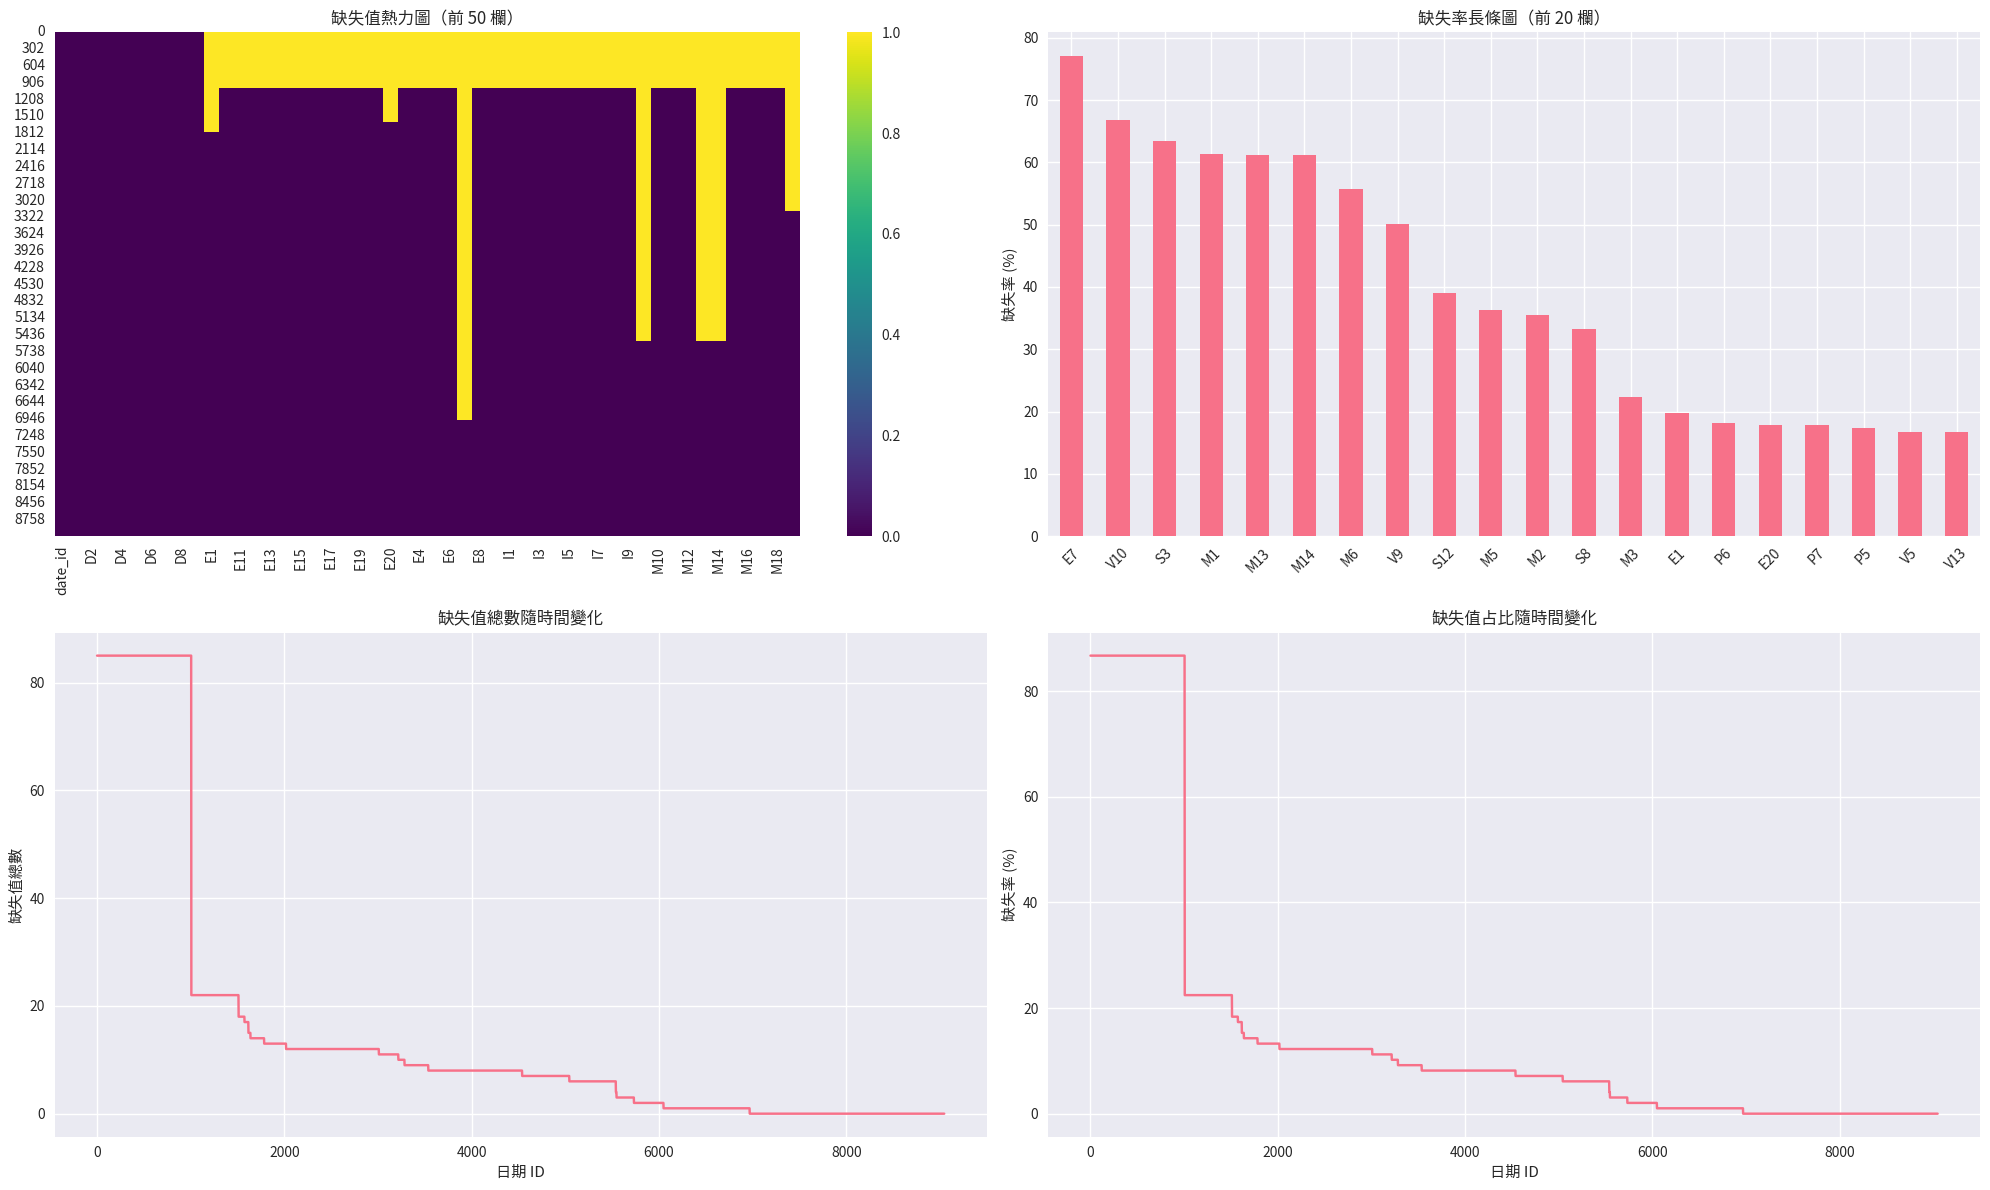

In [ ]:
# 缺失值分析
def analyze_missing_values(df, data_type="train"):
    print(f"{data_type.upper()} 缺失值分析：\n")

    # 統計整體缺失值
    total_missing_null = df.isnull()  # df.isnull() 用於判斷是否為缺失值
    total_missing = total_missing_null.sum().sum()  # 缺失值總數

    # 計算缺失值比例
    total_cells = df.shape[0] * df.shape[1]  # 計算總儲存格數
    missing_ratio = (total_missing / total_cells) * 100
    print(f"缺失值總數：{total_missing}")
    print(f"缺失率：{missing_ratio:.2f}%")

    # 分析每一欄位的缺失值
    missing_stats_sum = df.isnull().sum()
    missing_stats = missing_stats_sum.sort_values(ascending=False)  # 依缺失值數量遞減排序
    missing_stats = missing_stats[missing_stats > 0]

    if len(missing_stats) > 0:
        # 每個欄位缺失值占該欄位總列數的百分比
        missing_percent = (missing_stats / len(df)) * 100
        missing_df = pd.DataFrame({
            '缺失值數量': missing_stats,
            '缺失率 (%)': missing_percent.round(2)
        })
        print("\n缺失率最高的前 10 個欄位：")
        display(missing_df.head(10))

        # 缺失值視覺化
        if len(missing_stats) > 0:
            fig, axes = plt.subplots(2, 2, figsize=(20, 12))

            # 缺失值熱力圖（顯示前 50 個欄位）
            missing_matrix = df.isnull()
            sns.heatmap(
                missing_matrix.iloc[:, :50],
                cbar=True,
                ax=axes[0, 0],
                cmap='viridis'
            )
            axes[0, 0].set_title('缺失值熱力圖（前 50 欄）')

            # 缺失率長條圖（顯示前 20 個欄位）
            top_missing = missing_df.head(20)
            top_missing['缺失率 (%)'].plot(kind='bar', ax=axes[0, 1])
            axes[0, 1].set_title('缺失率長條圖（前 20 欄）')
            axes[0, 1].set_ylabel('缺失率 (%)')
            plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45)

            # 依日期維度分析缺失值
            if 'date_id' in df.columns:
                missing_by_date_day = df.groupby('date_id')  # 依日期分組

                # 缺失值總數隨時間變化的折線圖
                missing_by_date = missing_by_date_day.apply(
                    lambda x: x.isnull().sum().sum()
                )  # 計算每日缺失值總數
                axes[1, 0].plot(missing_by_date.index, missing_by_date.values)
                axes[1, 0].set_title('缺失值總數隨時間變化')
                axes[1, 0].set_xlabel('日期 ID')
                axes[1, 0].set_ylabel('缺失值總數')

                # 缺失值占比隨時間變化的折線圖
                missing_pct_by_date = (missing_by_date / df.shape[1]) * 100
                axes[1, 1].plot(
                    missing_pct_by_date.index,
                    missing_pct_by_date.values
                )
                axes[1, 1].set_title('缺失值占比隨時間變化')
                axes[1, 1].set_xlabel('日期 ID')
                axes[1, 1].set_ylabel('缺失率 (%)')

            plt.tight_layout()
            plt.show()

    return missing_stats


missing_analysis = analyze_missing_values(train_df, data_type="train")


In [ ]:
# 處理缺失值
def handle_missing_values(df, ref_stats=None, data_type="train", missing_threshold=0.5):  # 以 50% 作為缺失率閾值
    print(f"{data_type.upper()} 缺失值處理\n")
    df_clean = df.copy()

    # 處理訓練集的缺失值
    if data_type == "train":
        # 刪除缺失率過高的特徵欄位
        exclude_from_drop = [
            'date_id',
            'forward_returns',
            'risk_free_rate',
            'market_forward_excess_returns'
        ]
        missing_ratio = df_clean.isnull().sum() / len(df_clean)
        high_missing_cols = [
            col for col in missing_ratio.index
            if missing_ratio[col] > missing_threshold and col not in exclude_from_drop
        ]
        if len(high_missing_cols) > 0:
            df_clean = df_clean.drop(columns=high_missing_cols)
            print(f"刪除了 {len(high_missing_cols)} 個缺失率過高的特徵欄位：{list(high_missing_cols)}")

        # 對低缺失率欄位進行填補
        fill_stats = {}  # 儲存填補用的統計量，供測試集重複使用
        for col in df_clean.columns:
            if df_clean[col].isnull().sum() == 0:
                continue
            if df_clean[col].dtype in ['int64', 'float64']:
                median_val = df_clean[col].median()
                df_clean[col] = df_clean[col].fillna(median_val)
                fill_stats[col] = {'type': 'median', 'value': median_val}
            else:
                mode_val = df_clean[col].mode()[0]
                df_clean[col] = df_clean[col].fillna(mode_val)
                fill_stats[col] = {'type': 'mode', 'value': mode_val}

        print(f"已填補 {len(fill_stats)} 個欄位")
        final_missing = df_clean.isnull().sum().sum()
        print(f"缺失值處理後剩餘的缺失值數量：{final_missing}")
        return df_clean, fill_stats

    # 處理測試集
    else:
        if ref_stats is None:
            raise ValueError("測試集缺失值處理需要使用訓練集的填補規則")

        # 僅處理訓練集中存在的欄位
        valid_cols = [
            col for col in df_clean.columns
            if col in ref_stats and col != 'is_scored'
        ]
        for col in valid_cols:
            if df_clean[col].isnull().sum() == 0:
                continue
            stat = ref_stats[col]
            df_clean[col] = df_clean[col].fillna(stat['value'])

        # 處理 is_scored 欄位的缺失值，直接填補為 False
        if 'is_scored' in df_clean.columns and df_clean['is_scored'].isnull().sum() > 0:
            df_clean['is_scored'] = df_clean['is_scored'].fillna(False)

        # 測試集中剩餘仍有缺失值的欄位，使用自身中位數或眾數進行填補
        remaining_missing_cols = [
            col for col in df_clean.columns
            if df_clean[col].isnull().sum() > 0
            and col not in valid_cols
            and col != 'is_scored'
        ]
        for col in remaining_missing_cols:
            if df_clean[col].dtype in ['int64', 'float64']:
                df_clean[col] = df_clean[col].fillna(df_clean[col].median())
            else:
                df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

        print(f"已填補 {len(valid_cols) + len(remaining_missing_cols)} 個欄位的缺失值")
        return df_clean

    # （以下繪圖程式碼目前在 return 之後，實際執行時不會被觸發）
    plot_data = pd.DataFrame({
        '處理前': before_top20,
        '處理後': after_missing
    })
    plt.figure(figsize=(12, 8))
    plot_data.plot(kind='barh', stacked=False, colormap='Set2')
    plt.title('訓練集缺失率 Top 20 欄位處理前／後對比')
    plt.xlabel('缺失率（%）')
    plt.ylabel('特徵欄位')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


df_train_clean, fill_stats = handle_missing_values(
    train_df,
    ref_stats=None,
    data_type="train",
    missing_threshold=0.5
)


TRAIN 缺失值處理

刪除了 8 個缺失率過高的特徵欄位：['E7', 'M1', 'M13', 'M14', 'M6', 'S3', 'V10', 'V9']
已填補 77 個欄位
缺失值處理後剩餘的缺失值數量：0


In [ ]:
def analyze_outliers(df, target_col="market_forward_excess_returns", method="iqr"):
    """分析訓練集中的異常值，並輸出邊界參數（供測試集重複使用）"""
    print(f"\n 資料清理：訓練集異常值分析（目標變數：{target_col}）")
    print("-" * 40)
    outlier_params = {}

    # 僅分析目標變數與數值型特徵（排除 is_scored）
    if target_col in df.columns:
        target_data = df[target_col].dropna()
        if method == "iqr":
            Q1 = target_data.quantile(0.25)
            Q3 = target_data.quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
        else:  # z-score 方法
            mean_val = target_data.mean()
            std_val = target_data.std()
            lower = mean_val - 3 * std_val
            upper = mean_val + 3 * std_val

        # 統計目標變數的異常值
        outliers = target_data[(target_data < lower) | (target_data > upper)]
        print(
            f"目標變數 {target_col} 的異常值數量：{len(outliers)} "
            f"({len(outliers) / len(target_data) * 100:.2f}%)"
        )
        print(f"異常值邊界（{method}）：[{lower:.6f}, {upper:.6f}]")
        outlier_params[target_col] = {
            'lower': lower,
            'upper': upper,
            'method': method
        }
    else:
        print(f"訓練集中未找到 {target_col}，略過目標變數的異常值分析")

    # 分析數值型特徵的異常值（排除 is_scored，僅儲存邊界）
    numeric_cols = [
        col for col in df.columns
        if col not in [target_col, 'is_scored']
        and df[col].dtype in ['int64', 'float64']
    ]

    for col in numeric_cols[:5]:  # 僅分析前 5 個特徵，避免輸出過多
        feat_data = df[col].dropna()
        if len(feat_data) < 30:
            continue

        if method == "iqr":
            Q1 = feat_data.quantile(0.25)
            Q3 = feat_data.quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
        else:
            mean_val = feat_data.mean()
            std_val = feat_data.std()
            lower = mean_val - 3 * std_val
            upper = mean_val + 3 * std_val

        outlier_params[col] = {
            'lower': lower,
            'upper': upper
        }

    print(f"已儲存 {len(outlier_params)} 個欄位的異常值邊界（特徵欄位，不包含 is_scored）")
    return outlier_params


In [ ]:
def handle_outliers(df, outlier_params, data_type="train"):
    """處理異常值（使用截斷法，測試集沿用訓練集的邊界，不處理 is_scored）"""
    print(f"\n 資料清理：{data_type.upper()} 異常值處理")
    print("-" * 40)
    df_clean = df.copy()

    # 僅處理具有邊界參數、目前資料集中存在，且非 is_scored 的欄位
    valid_cols = [
        col for col in df_clean.columns
        if col in outlier_params and col != 'is_scored'
    ]

    for col in valid_cols:
        params = outlier_params[col]
        # 截斷異常值（以邊界值取代）
        df_clean[col] = df_clean[col].clip(
            lower=params['lower'],
            upper=params['upper']
        )

    print(
        f"已完成 {len(valid_cols)} 個欄位的異常值處理 "
        f"（以邊界值截斷，不包含 is_scored）"
    )
    return df_clean


In [ ]:
def remove_zero_variance_features(train_df, test_df, exclude_cols=['date_id', 'forward_returns', 'risk_free_rate', 'market_forward_excess_returns', 'is_scored']):
    """
    移除零方差特徵（所有樣本值相同的特徵）：
    - 訓練集：識別並刪除零方差特徵，記錄刪除列表（排除 is_scored，因訓練集無該列）
    - 測試集：沿用訓練集的刪除列表，保持特徵一致性，保留 is_scored
    """
    print(f"\n 資料清理：移除零方差特徵")
    print("-"*40)

    # 篩選訓練集的數值特徵（排除特殊欄位，訓練集無 is_scored，無需額外處理）
    train_num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    train_num_cols = [col for col in train_num_cols if col not in exclude_cols]

    # 識別訓練集零方差特徵（標準差≈0）
    zero_var_cols = []
    for col in train_num_cols:
        std = train_df[col].std()
        if std < 1e-8:  # 標準差接近 0，視為零方差
            zero_var_cols.append(col)

    if zero_var_cols:
        print(f"找到 {len(zero_var_cols)} 個零方差特徵（訓練集）：{zero_var_cols}")
        # 訓練集刪除零方差特徵
        train_clean = train_df.drop(columns=zero_var_cols)
        # 測試集刪除相同的特徵（保留 is_scored）
        test_clean = test_df.drop(columns=[col for col in zero_var_cols if col in test_df.columns and col != 'is_scored'])
        print(f"已從訓練集與測試集刪除零方差特徵（保留 'is_scored'）")
    else:
        print("未發現零方差特徵")
        train_clean = train_df.copy()
        test_clean = test_df.copy()

    return train_clean, test_clean


In [ ]:
def data_cleaning_pipeline(train_df, test_df, missing_threshold=0.5):
    """資料清洗完整流程：去重 → 缺失值處理 → 異常值處理 → 移除零方差特徵
       （適配 is_scored，嚴格區分訓練集/測試集列）
    """
    print("="*60)
    print(" 完整資料清洗流程")
    print("="*60)

    # 1. 處理重複值
    train_clean = handle_duplicates(train_df, "train")
    test_clean = handle_duplicates(test_df, "test")

    # 2. 處理缺失值（以訓練集為主）
    train_missing_stats = analyze_missing_values(train_clean, "train")
    train_clean, fill_stats = handle_missing_values(train_clean, data_type="train", missing_threshold=missing_threshold)
    test_clean = handle_missing_values(test_clean, ref_stats=fill_stats, data_type="test")

    # 3. 處理異常值（以訓練集為主）
    outlier_params = analyze_outliers(train_clean)
    train_clean = handle_outliers(train_clean, outlier_params, "train")
    test_clean = handle_outliers(test_clean, outlier_params, "test")

    # 4. 移除零方差特徵（避免標準化除以0警告）
    train_clean, test_clean = remove_zero_variance_features(train_clean, test_clean)

    # 5. 對齊訓練集和測試集列：嚴格區分雙方列，is_scored 僅保留於測試集
    # 訓練集列：共有列 + 訓練集特有目標列
    common_cols = list(set(train_clean.columns) & set(test_clean.columns))
    train_target_cols = ['forward_returns', 'risk_free_rate', 'market_forward_excess_returns']
    train_final_cols = common_cols.copy()
    for col in train_target_cols:
        if col in train_clean.columns and col not in train_final_cols:
            train_final_cols.append(col)
    if "date_id" in train_clean.columns and "date_id" not in train_final_cols:
        train_final_cols.append("date_id")

    # 測試集列：共有列 + 測試集特有 is_scored 列 + 測試集可能保留的目標列（對齊後）
    test_final_cols = common_cols.copy()
    if 'is_scored' in test_clean.columns and 'is_scored' not in test_final_cols:
        test_final_cols.append('is_scored')
    if "date_id" in test_clean.columns and "date_id" not in test_final_cols:
        test_final_cols.append("date_id")

    # 篩選列（確保只選擇存在的列）
    train_clean = train_clean[train_final_cols].copy()
    test_clean = test_clean[test_final_cols].copy()

    print(f"\n 資料清洗完成！")
    print(f"訓練集清洗後形狀: {train_clean.shape}")
    print(f"測試集清洗後形狀: {test_clean.shape}")
    print(f"訓練集前10個欄位: {list(train_clean.columns)[:10]}...")
    print(f"測試集前10個欄位: {list(test_clean.columns)[:10]}...")

    # 生成特徵分類（區分訓練集/測試集）
    train_feature_categories = categorize_features(train_clean, is_test=False)
    test_feature_categories = categorize_features(test_clean, is_test=True)

    # 特徵篩選等後續步驟用訓練集分類，測試集復用訓練集特徵邏輯
    return train_clean, test_clean, train_feature_categories


 完整資料清洗流程

 資料清理：TRAIN 重複值處理
----------------------------------------
已刪除 0 筆完全重複的資料列
重複值處理後的資料維度：(9048, 98)

 資料清理：TEST 重複值處理
----------------------------------------
已刪除 0 筆完全重複的資料列
重複值處理後的資料維度：(9048, 98)
TRAIN 缺失值分析：

缺失值總數：137675
缺失率：15.53%

缺失率最高的前 10 個欄位：


,缺失值數量,缺失率 (%)
E7,6969,77.02
V10,6049,66.85
S3,5733,63.36
M1,5547,61.31
M13,5540,61.23
M14,5540,61.23
M6,5043,55.74
V9,4539,50.17
S12,3537,39.09
M5,3283,36.28


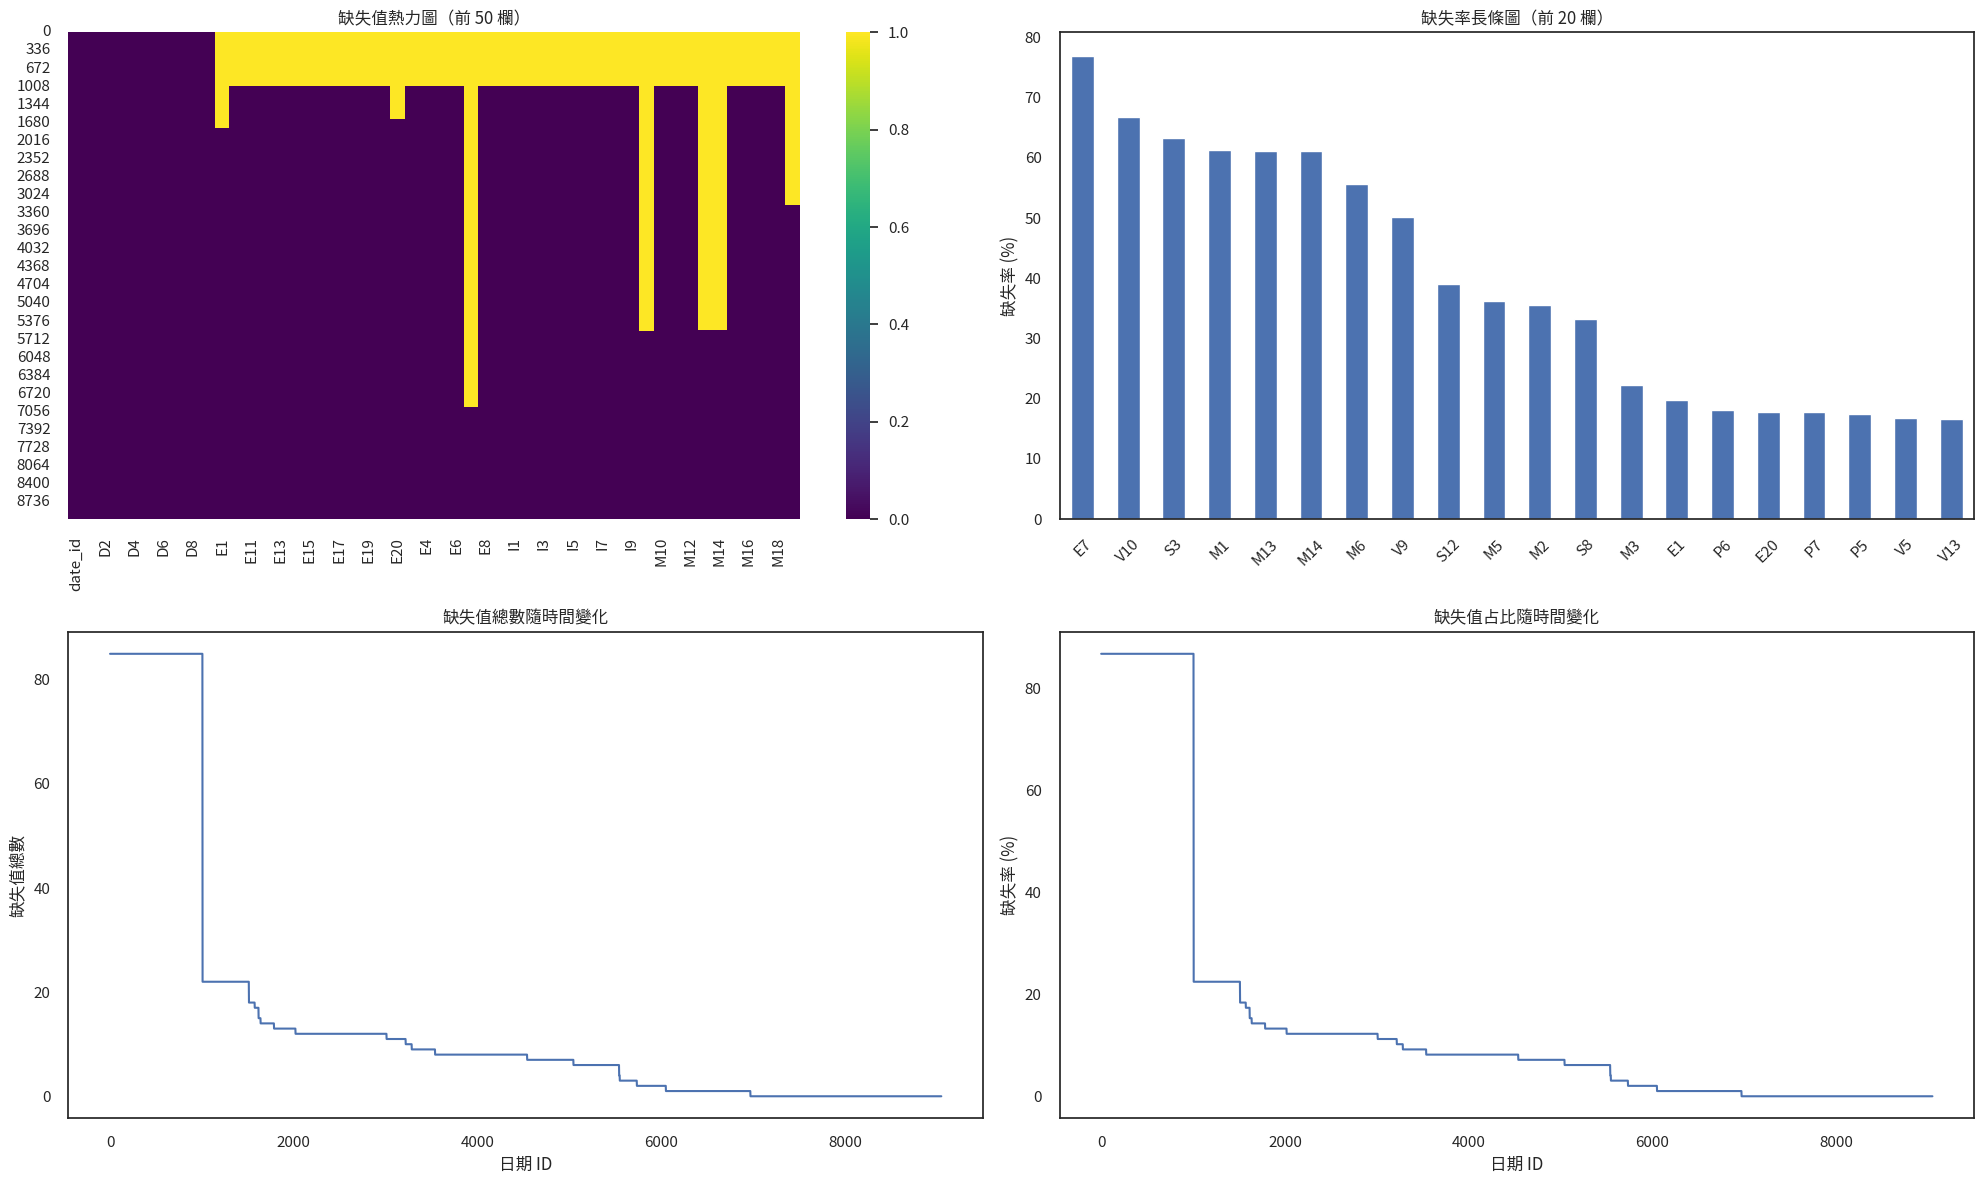

TRAIN 缺失值處理

刪除了 8 個缺失率過高的特徵欄位：['E7', 'M1', 'M13', 'M14', 'M6', 'S3', 'V10', 'V9']
已填補 77 個欄位
缺失值處理後剩餘的缺失值數量：0
TEST 缺失值處理

已填補 85 個欄位的缺失值

 資料清理：訓練集異常值分析（目標變數：market_forward_excess_returns）
----------------------------------------
目標變數 market_forward_excess_returns 的異常值數量：598 (6.61%)
異常值邊界（iqr）：[-0.020081, 0.020798]
已儲存 6 個欄位的異常值邊界（特徵欄位，不包含 is_scored）

 資料清理：TRAIN 異常值處理
----------------------------------------
已完成 6 個欄位的異常值處理 （以邊界值截斷，不包含 is_scored）

 資料清理：TEST 異常值處理
----------------------------------------
已完成 6 個欄位的異常值處理 （以邊界值截斷，不包含 is_scored）

 資料清理：移除零方差特徵
----------------------------------------
找到 3 個零方差特徵（訓練集）：['D1', 'D2', 'D3']
已從訓練集與測試集刪除零方差特徵（保留 'is_scored'）

 資料清洗完成！
訓練集清洗後形狀: (9048, 87)
測試集清洗後形狀: (9048, 87)
訓練集前10個欄位: ['I4', 'I7', 'M10', 'I9', 'M12', 'S6', 'P2', 'M3', 'E12', 'I5']...
測試集前10個欄位: ['I4', 'I7', 'M10', 'I9', 'M12', 'S6', 'P2', 'M3', 'E12', 'I5']...
特徵分類：
實際存在的特殊欄位：['date_id', 'forward_returns', 'risk_free_rate', 'market_forward_excess_returns']

Market_Dynamics：1

In [ ]:
train_clean, test_clean, feature_categories = data_cleaning_pipeline(train_df, test_df)

## 特徵篩選

特徵選擇：相關性分析
----------------------------------------
Top 10 與 market_forward_excess_returns 相關性最強的特徵：
forward_returns    0.9769
V13                0.0568
S5                 0.0362
V7                 0.0344
D8                 0.0267
E19                0.0263
M17                0.0251
M2                 0.0234
S6                 0.0217
S12                0.0207
Name: market_forward_excess_returns, dtype: float64


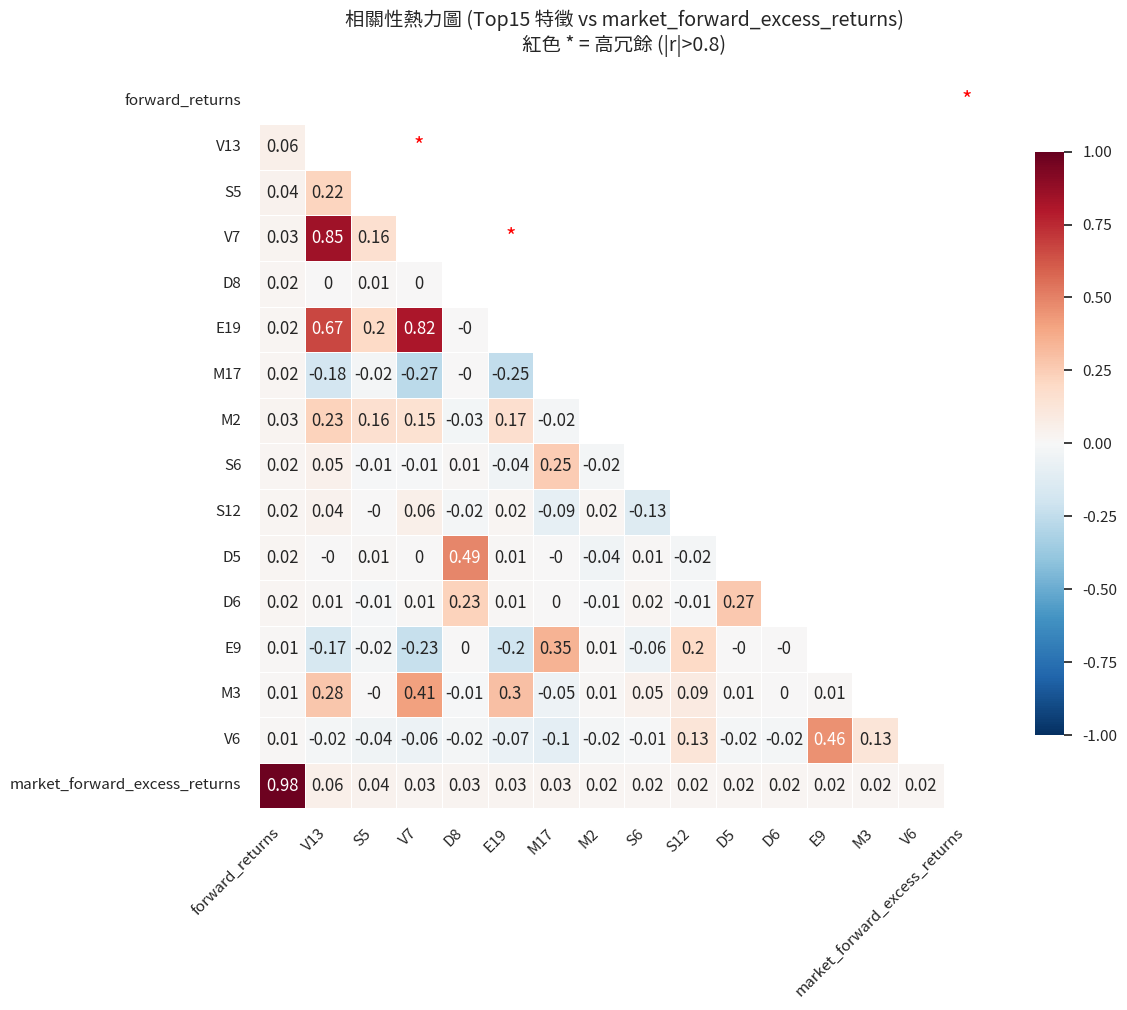

共發現 13 對高相關特徵 (|r|>0.8)


In [ ]:
def analyze_correlations(df, feature_categories, target_col="market_forward_excess_returns", is_test=False, plot_fig=True):
    """相關性分析：
       1. 特徵與目標變數（forward_returns）相關性
       2. 類別內高冗餘特徵對（|r|>0.8）
    """
    print("特徵選擇：相關性分析")
    print("-"*40)

    # 初始化結果字典
    corr_results = {
        'target_corr': pd.Series(),
        'high_corr_pairs': []
    }

    # 1️⃣ 特徵 - 目標變數相關性分析
    if target_col in df.columns:
        valid_cols = df.columns[df.notna().any()]  # 所有非空列
        if is_test:
            valid_cols = [col for col in valid_cols if col != 'is_scored']  # 測試集排除 is_scored
        corr_matrix = df[valid_cols].corr()  # 皮爾森相關係數矩陣
        target_corr = corr_matrix[target_col].sort_values(ascending=False)
        target_corr = target_corr.drop(target_col, errors='ignore')  # 去掉自相關
        corr_results['target_corr'] = target_corr

        print(f"Top 10 與 {target_col} 相關性最強的特徵：")
        print(target_corr.head(10).round(4))

        # 可視化熱力圖（Top15 特徵 + 目標列）
        if plot_fig:
            top_feats = target_corr.head(15).index.tolist()
            plot_cols = top_feats + [target_col]
            plot_corr = corr_matrix.loc[plot_cols, plot_cols]

            plt.figure(figsize=(12, 10))

            sns.set_style("white", rc={
            "font.family": "sans-serif",
            "font.sans-serif": [FONT_NAME],
            "axes.unicode_minus": False
            })

            mask = np.triu(np.ones_like(plot_corr, dtype=bool)) if len(plot_cols) > 1 else None

            heatmap = sns.heatmap(
                plot_corr.round(2),
                mask=mask,
                annot=True,
                cmap="RdBu_r",
                center=0,
                vmin=-1, vmax=1,
                square=True,
                linewidths=0.5,
                cbar_kws={"shrink": 0.8}
            )

            # 標注高冗餘特徵對（|r|>0.8）
            for i in range(len(plot_cols)):
                for j in range(i+1, len(plot_cols)):
                    corr_val = plot_corr.iloc[i, j]
                    if abs(corr_val) > 0.8:
                        heatmap.text(
                            j+0.5, i+0.5, "*",
                            ha="center", va="center",
                            color="red", fontsize=16, fontweight="bold"
                        )

            plt.title(f"相關性熱力圖 (Top15 特徵 vs {target_col})\n紅色 * = 高冗餘 (|r|>0.8)", fontsize=14, pad=20)
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()
    else:
        print(f"{target_col} 未找到，跳過特徵-目標相關性分析")

    # 2️⃣ 類別內高冗餘特徵對分析
    for cat, feats in feature_categories.items():
        if cat == 'Special' or len(feats) < 2:
            continue
        valid_feats = [f for f in feats if f in df.columns]
        if is_test:
            valid_feats = [f for f in valid_feats if f != 'is_scored']
        if len(valid_feats) < 2:
            continue

        cat_corr = df[valid_feats].corr()
        for i in range(len(valid_feats)):
            for j in range(i+1, len(valid_feats)):
                corr_val = cat_corr.iloc[i, j]
                if abs(corr_val) > 0.8:  # 高冗餘特徵對
                    corr_results['high_corr_pairs'].append((valid_feats[i], valid_feats[j], corr_val))

    print(f"共發現 {len(corr_results['high_corr_pairs'])} 對高相關特徵 (|r|>0.8)")
    return corr_results

# 範例呼叫
corr_results = analyze_correlations(train_clean, feature_categories, is_test=False)


特徵選擇：重要性分析
----------------------------------------
Top 15 重要特徵:
     Composite_Score
V3            0.9277
P1            0.8855
V4            0.8494
I7            0.8193
P13           0.8133
E14           0.7771
I6            0.7771
S4            0.7470
E4            0.7410
S11           0.7410
D9            0.7289
V2            0.7289
S10           0.7289
P4            0.7048
M9            0.7048


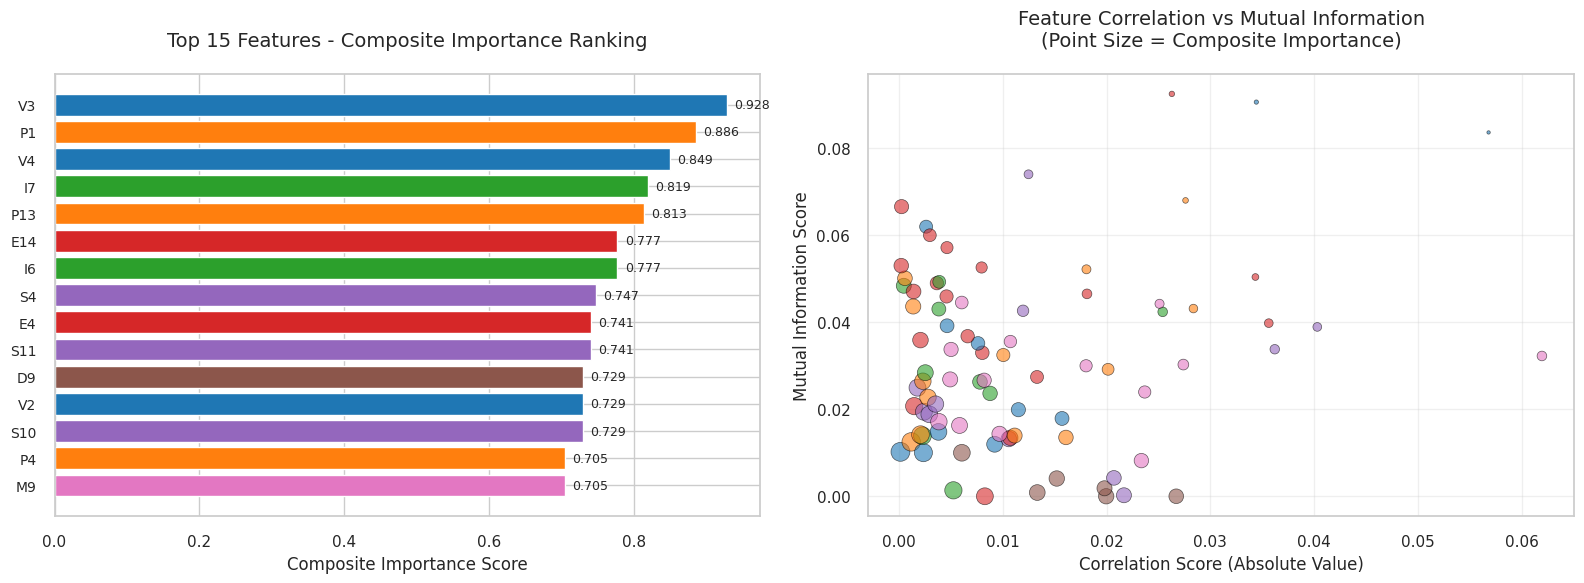

In [ ]:
def analyze_feature_importance(df, feature_categories, target_col="market_forward_excess_returns", max_feats=100, plot_fig=True):
    """
    特徵重要性分析：
    - 綜合線性相關性（Correlation）與非線性相關性（Mutual Information）
    - 生成綜合重要性排序（Composite Score）

    參數：
        df: DataFrame，數值特徵 + 目標列
        feature_categories: dict，特徵分類
        target_col: str，目標列名稱
        max_feats: int，最多計算特徵數量
        plot_fig: bool，是否繪圖
    """
    print("特徵選擇：重要性分析")
    print("-"*40)

    if target_col not in df.columns:
        print(f"{target_col} 未找到，跳出分析")
        return pd.DataFrame()

    # 1️⃣ 篩選有效特徵（排除 Special 類與 is_scored）
    feat_cols = []
    feat_to_cat = {}
    for cat, feats in feature_categories.items():
        if cat != 'Special':
            for f in feats:
                if f in df.columns and f != 'is_scored':
                    feat_cols.append(f)
                    feat_to_cat[f] = cat
    feat_cols = list(set(feat_cols))  # 去重
    if len(feat_cols) > max_feats:
        feat_cols = feat_cols[:max_feats]
        print(f"限制 {max_feats} 特徵以保證計算效率")

    # 2️⃣ 準備特徵矩陣與目標向量
    X = df[feat_cols].copy()
    y = df[target_col].dropna()
    X = X.loc[y.index].fillna(X.median())  # 對齊 y，並填充缺失值

    # 3️⃣ 計算線性相關性
    corr_importance = abs(X.corrwith(y)).sort_values(ascending=False)

    # 4️⃣ 計算非線性相關性（互信息）
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    mi_importance = pd.Series(mutual_info_regression(X_scaled, y, random_state=42),
                              index=feat_cols).sort_values(ascending=False)

    # 5️⃣ 整合為綜合重要性
    importance_df = pd.DataFrame({
        'Corr_Score': corr_importance.reindex(feat_cols),
        'MI_Score': mi_importance.reindex(feat_cols),
        'Category': [feat_to_cat.get(f, 'Unknown') for f in feat_cols]
    }).fillna(0)

    # 百分位排名 + 綜合分數
    importance_df['Corr_Rank'] = importance_df['Corr_Score'].rank(pct=True, ascending=False)
    importance_df['MI_Rank'] = importance_df['MI_Score'].rank(pct=True, ascending=False)
    importance_df['Composite_Score'] = (importance_df['Corr_Rank'] + importance_df['MI_Rank']) / 2
    importance_df = importance_df.sort_values('Composite_Score', ascending=False)

    print("Top 15 重要特徵:")
    print(importance_df[['Composite_Score']].head(15).round(4))

    # 6️⃣ 可視化（條形圖 + 散點圖）
    if plot_fig:
        plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
        plt.rcParams['axes.unicode_minus'] = False
        sns.set_style("whitegrid")
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # 條形圖：Top15
        top15_df = importance_df.head(15)
        categories = top15_df['Category'].unique()
        colors = sns.color_palette("tab10", n_colors=len(categories))
        cat_color_map = dict(zip(categories, colors))

        bars = ax1.barh(range(len(top15_df)), top15_df['Composite_Score'],
                        color=[cat_color_map[cat] for cat in top15_df['Category']])
        ax1.set_yticks(range(len(top15_df)))
        ax1.set_yticklabels(top15_df.index, fontsize=10)
        ax1.set_xlabel('Composite Importance Score', fontsize=12)
        ax1.set_title('Top 15 Features - Composite Importance Ranking', fontsize=14, pad=20)
        ax1.invert_yaxis()
        for i, bar in enumerate(bars):
            ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                     f'{bar.get_width():.3f}', ha='left', va='center', fontsize=9)

        # 散點圖：線性 vs 非線性
        ax2.scatter(importance_df['Corr_Score'], importance_df['MI_Score'],
                   s=importance_df['Composite_Score']*200, alpha=0.6,
                   c=[cat_color_map.get(cat, 'gray') for cat in importance_df['Category']],
                   edgecolors='black', linewidth=0.5)
        ax2.set_xlabel('Correlation Score (Absolute Value)', fontsize=12)
        ax2.set_ylabel('Mutual Information Score', fontsize=12)
        ax2.set_title('Feature Correlation vs Mutual Information\n(Point Size = Composite Importance)', fontsize=14, pad=20)
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return importance_df

# 範例呼叫
importance_df = analyze_feature_importance(train_clean, feature_categories)


特徵選擇：穩定性分析
----------------------------------------
穩定性結果: 25/83 個特徵是穩定的 (CV<0.5)


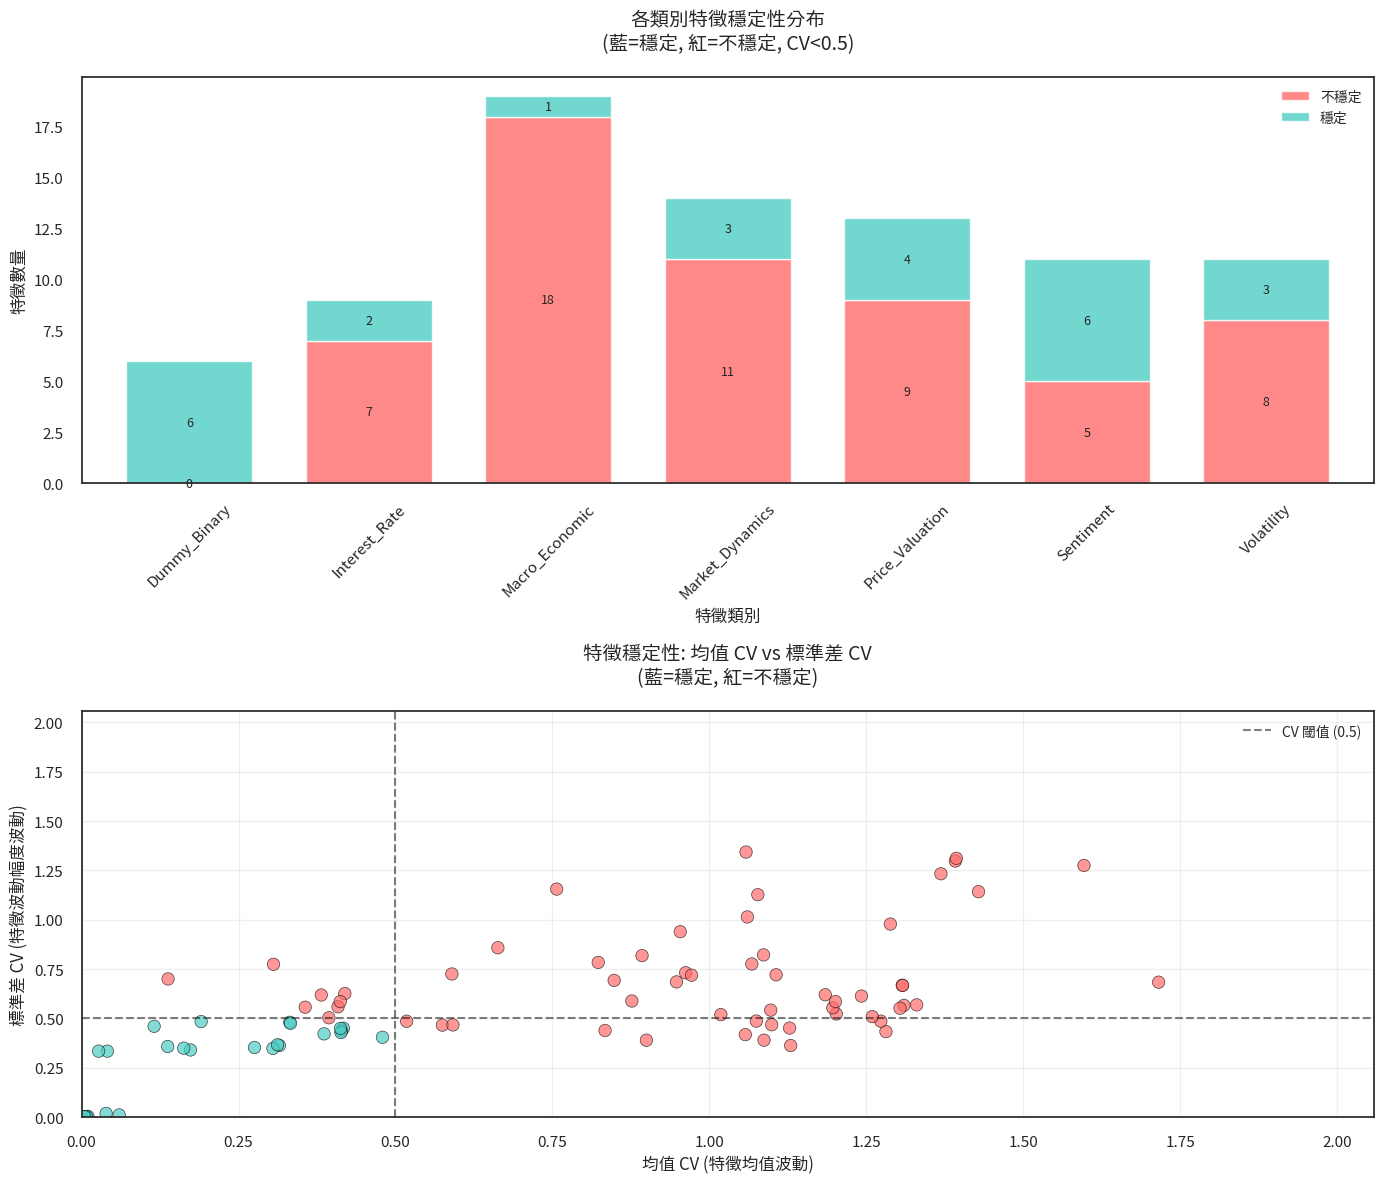

In [ ]:
def analyze_feature_stability(df, feature_categories, time_col="date_id", n_periods=10, plot_fig=True):
    # 按時間欄位將資料劃分為 n_periods 個周期
    # 用「變異係數（CV）」衡量均值與標準差的波動程度，CV = 標準差 / 均值
    """特徵穩定性分析：基於時間周期的變異係數（CV 越小越穩定）"""
    print("特徵選擇：穩定性分析")
    print("-"*40)

    if time_col not in df.columns:
        print(f"{time_col} 沒有找到，跳過穩定性分析")
        return {}

    # 按時間排序
    df_sorted = df.sort_values(time_col).reset_index(drop=True)  # 按時間欄升序排序並重置索引
    period_size = len(df_sorted) // n_periods  # 計算每個周期的樣本數
    if period_size < 30:
        print(f"每個周期樣本數({period_size}) 太少，跳過穩定性分析")
        return {}

    stability_results = {}  # 初始化空字典，用於存儲最終穩定性結果

    # 分析非特殊類別特徵
    for cat, feats in feature_categories.items():
        if cat == 'Special' or len(feats) == 0:
            continue
        cat_stability = {}  # 初始化空字典，用於存儲當前類別的特徵穩定性結果
        valid_feats = [f for f in feats if f in df_sorted.columns and f != 'is_scored']
        for feat in valid_feats:  # 遍歷當前類別的每個有效特徵
            period_stats = []  # 初始化空列表，用於存儲每個周期的統計資訊（均值 + 標準差）
            # 計算每個周期的均值與標準差
            for i in range(n_periods):
                start = i * period_size
                end = (i+1) * period_size if i < n_periods-1 else len(df_sorted)
                period_data = df_sorted.iloc[start:end][feat].dropna()  # 提取當前周期特徵資料並處理缺失值
                if len(period_data) >= 10:
                    period_stats.append({'mean': period_data.mean(), 'std': period_data.std()})  # 僅保留樣本數足夠的周期統計資訊
            # 計算變異係數（CV）
            if len(period_stats) >= 3:  # 至少需要 3 個有效周期（不足 3 個無法衡量波動，穩定性判斷不可靠）
                means = [s['mean'] for s in period_stats]  # 每個有效周期的均值
                stds = [s['std'] for s in period_stats]    # 每個有效周期的標準差
                mean_cv = np.std(means) / np.mean(np.abs(means)) if np.mean(np.abs(means)) != 0 else np.inf  # 均值 CV
                std_cv = np.std(stds) / np.mean(stds) if np.mean(stds) != 0 else np.inf  # 標準差 CV
                cat_stability[feat] = {
                    'mean_cv': mean_cv,
                    'std_cv': std_cv,
                    'stable': mean_cv < 0.5 and std_cv < 0.5,
                    'category': cat
                }  # 儲存當前特徵的穩定性結果
        stability_results[cat] = cat_stability

    # 統計穩定特徵
    total_stable = sum([1 for cat_dict in stability_results.values() for f in cat_dict.values() if f['stable']])
    total_analyzed = sum([len(cat_dict) for cat_dict in stability_results.values()])
    print(f"穩定性結果: {total_stable}/{total_analyzed} 個特徵是穩定的 (CV<0.5)")

    # 可視化穩定性結果
    if plot_fig and total_analyzed > 0:
        # 將字典結果轉為 DataFrame 以便繪圖
        stability_df = pd.DataFrame()
        for cat_dict in stability_results.values():
            stability_df = pd.concat([stability_df, pd.DataFrame.from_dict(cat_dict, orient='index')], axis=0)
        stability_df.reset_index(inplace=True)
        stability_df.rename(columns={'index': 'feature'}, inplace=True)

        # 設定繪圖樣式
        sns.set_style("white", rc={
        "font.family": "sans-serif",
        "font.sans-serif": [FONT_NAME],
        "axes.unicode_minus": False
        })

        fig, axes = plt.subplots(2, 1, figsize=(14, 12))

        # 子圖1：類別穩定性分布（堆疊條形圖）
        ax1 = axes[0]
        cat_stable_stats = stability_df.groupby('category')['stable'].value_counts().unstack(fill_value=0)
        if True not in cat_stable_stats.columns:
            cat_stable_stats[True] = 0
        if False not in cat_stable_stats.columns:
            cat_stable_stats[False] = 0
        cat_stable_stats.plot(kind='bar', stacked=True, ax=ax1,
                              color=['#FF6B6B', '#4ECDC4'], alpha=0.8, width=0.7)
        ax1.set_xlabel('特徵類別', fontsize=12)
        ax1.set_ylabel('特徵數量', fontsize=12)
        ax1.set_title('各類別特徵穩定性分布\n(藍=穩定, 紅=不穩定, CV<0.5)', fontsize=14, pad=20)
        ax1.legend(['不穩定', '穩定'], loc='upper right', fontsize=10)
        ax1.tick_params(axis='x', rotation=45)
        for container in ax1.containers:
            ax1.bar_label(container, label_type='center', fontsize=9)

        # 子圖2：特徵 CV 散點圖（均值 CV vs 標準差 CV）
        ax2 = axes[1]
        scatter = ax2.scatter(
            x=stability_df['mean_cv'],
            y=stability_df['std_cv'],
            c=stability_df['stable'].map({True: '#4ECDC4', False: '#FF6B6B'}),
            s=80,
            alpha=0.7,
            edgecolors='black', linewidth=0.5
        )
        ax2.axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='CV 閾值 (0.5)')
        ax2.axhline(y=0.5, color='black', linestyle='--', alpha=0.5)
        ax2.set_xlabel('均值 CV (特徵均值波動)', fontsize=12)
        ax2.set_ylabel('標準差 CV (特徵波動幅度波動)', fontsize=12)
        ax2.set_title('特徵穩定性: 均值 CV vs 標準差 CV\n(藍=穩定, 紅=不穩定)', fontsize=14, pad=20)
        ax2.legend(loc='upper right', fontsize=10)
        ax2.grid(True, alpha=0.3)

        max_cv = min(stability_df[['mean_cv', 'std_cv']].max().max() * 1.2, 5)
        ax2.set_xlim(0, max_cv)
        ax2.set_ylim(0, max_cv)

        extreme_feats = stability_df[(stability_df['mean_cv'] > 2) | (stability_df['std_cv'] > 2)]
        for idx, row in extreme_feats.iterrows():
            ax2.annotate(
                row['feature'],
                xy=(row['mean_cv'], row['std_cv']),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
            )

        plt.tight_layout()
        plt.show()

    return stability_results

stability_results = analyze_feature_stability(train_clean, feature_categories)


完整特徵選擇流程
初始非特殊特徵：83
特徵選擇：相關性分析
----------------------------------------
Top 10 與 market_forward_excess_returns 相關性最強的特徵：
forward_returns    0.9769
V13                0.0568
S5                 0.0362
V7                 0.0344
D8                 0.0267
E19                0.0263
M17                0.0251
M2                 0.0234
S6                 0.0217
S12                0.0207
Name: market_forward_excess_returns, dtype: float64
共發現 13 對高相關特徵 (|r|>0.8)
特徵選擇：重要性分析
----------------------------------------
Top 15 重要特徵:
     Composite_Score
V3            0.9277
P1            0.8855
V4            0.8494
I7            0.8193
P13           0.8133
E14           0.7771
I6            0.7771
S4            0.7470
E4            0.7410
S11           0.7410
D9            0.7289
V2            0.7289
S10           0.7289
P4            0.7048
M9            0.7048


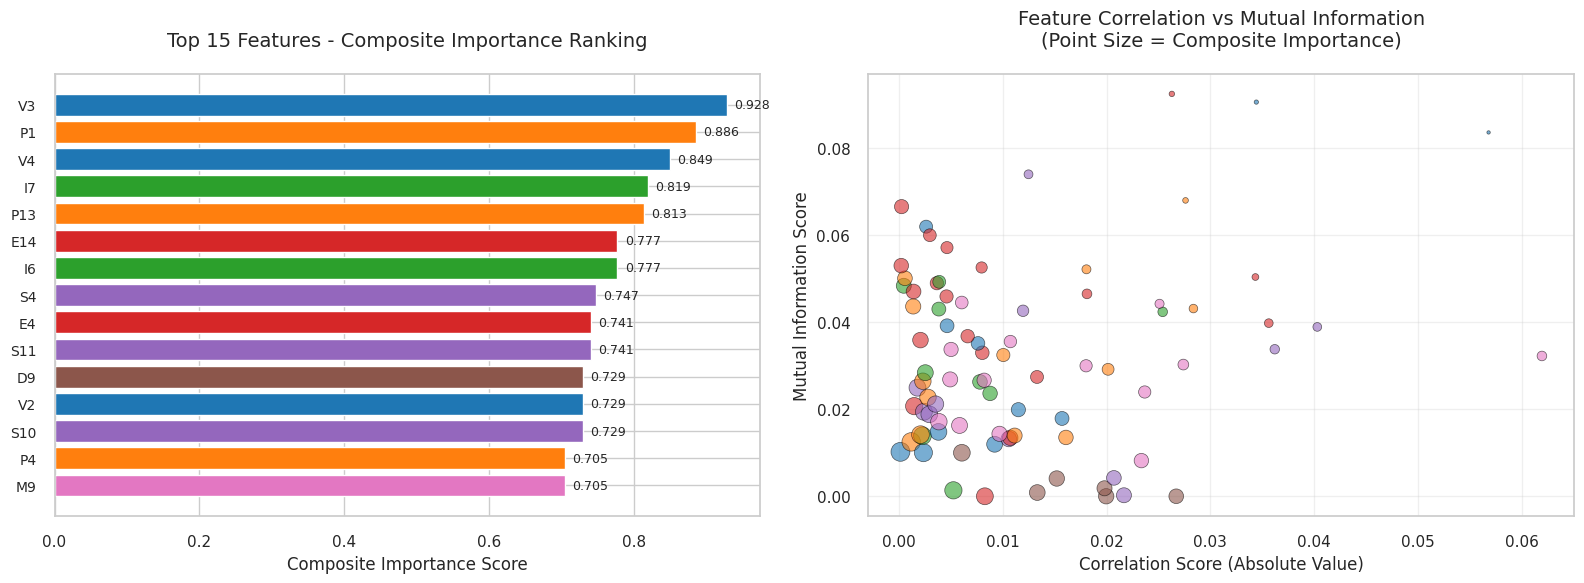

特徵選擇：穩定性分析
----------------------------------------
穩定性結果: 25/83 個特徵是穩定的 (CV<0.5)


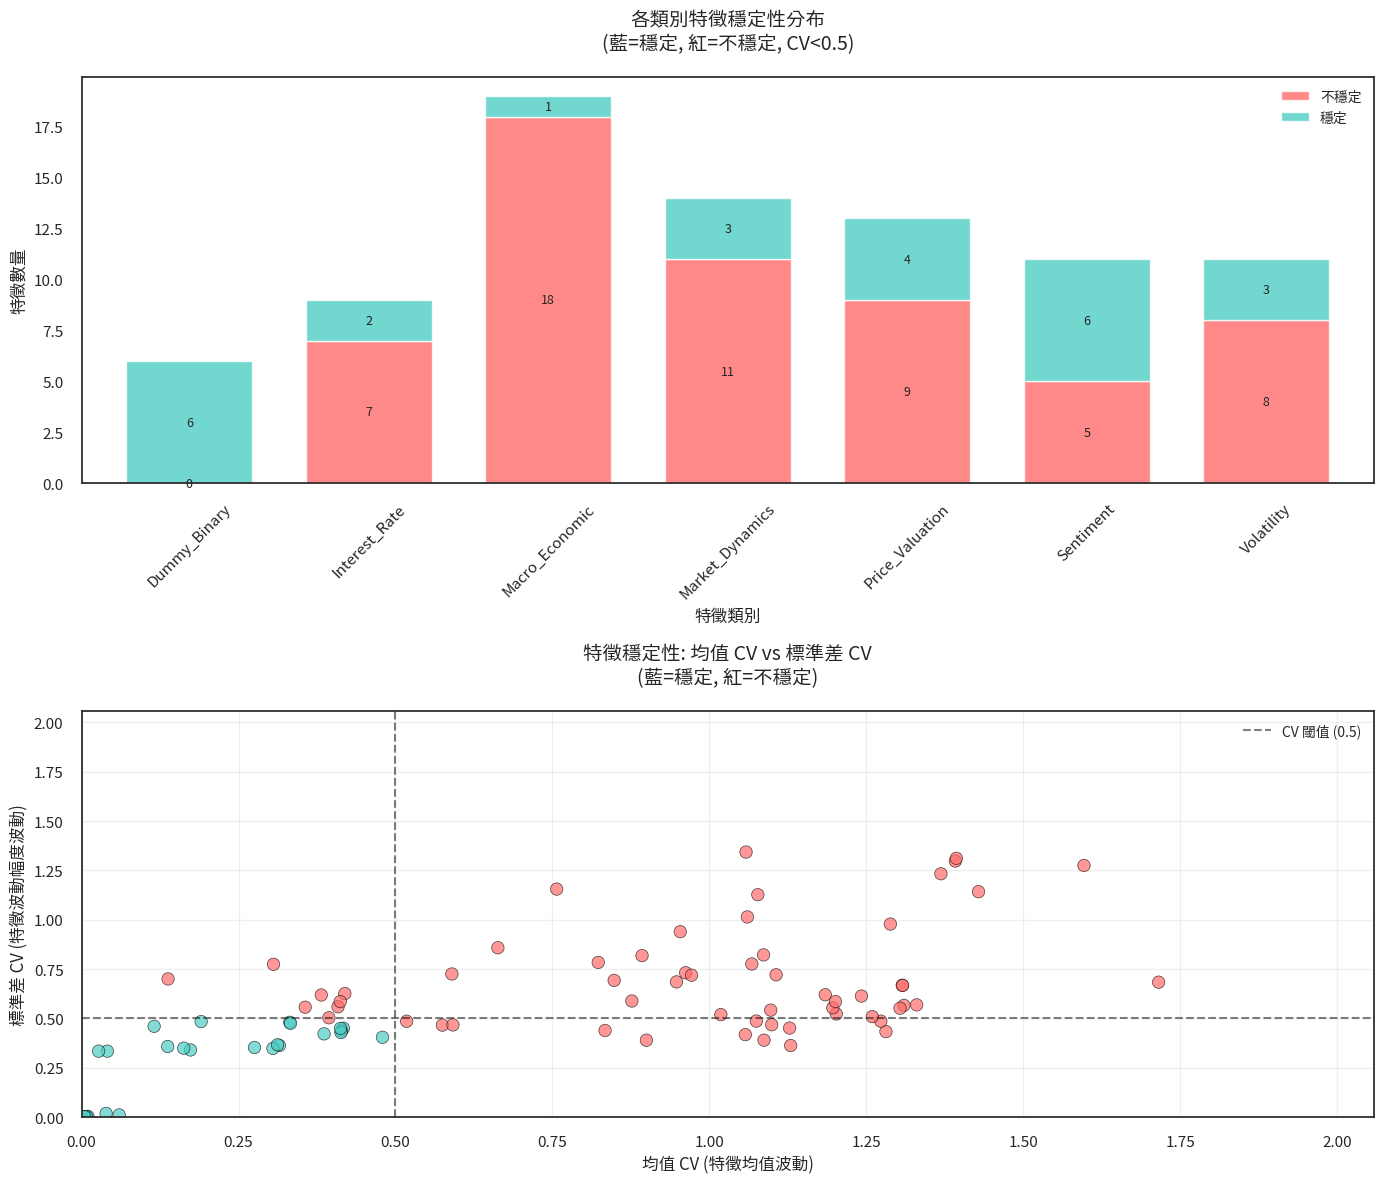

規則 1（高重要性）：保留 58 個特徵
規則 2（穩定性）：保留 22 個特徵
規則 3（目標相關性）：保留 8 個特徵
特徵選擇完成！
最終特徵數量（訓練集）：12
最終特徵數量（測試集）：12
篩選後訓練集形狀：(9048, 12)
篩選後測試集形狀：(9048, 12)

最終篩選結果彙整
訓練集最終特徵（12 個）：
  ['D4', 'D5', 'D6', 'D7', 'D8', 'P3', 'S6', 'S9', 'date_id', 'forward_returns', 'market_forward_excess_returns', 'risk_free_rate']

測試集最終特徵（12 個）：
  ['D4', 'D5', 'D6', 'D7', 'D8', 'P3', 'S6', 'S9', 'date_id', 'forward_returns', 'market_forward_excess_returns', 'risk_free_rate']

篩選後訓練集形狀：(9048, 12)
篩選後測試集形狀：(9048, 12)


In [ ]:
def sns_set_tc(style="white"):
    sns.set_style(style, rc={
        "font.family": "sans-serif",
        "font.sans-serif": [FONT_NAME],
        "axes.unicode_minus": False
    })
import pandas as pd

def feature_selection_pipeline(
    train_clean,
    test_clean,
    feature_categories,
    target_col="market_forward_excess_returns",
    corr_results=None,
    importance_df=None,
    stability_results=None,
):
    """
    特徵篩選流程：高重要性 → 穩定性 → 目標相關性 → 低冗餘
    從訓練集與測試集中篩出「重要、穩定、相關、低冗餘」的特徵
    """

    print("=" * 60)
    print("完整特徵選擇流程")
    print("=" * 60)

    # 初始特徵集合（非 Special 類別，排除 is_scored）
    initial_feats = []  # 初始化空列表：存放「非 Special + 排除 is_scored」的初始特徵
    for cat, feats in feature_categories.items():
        if cat != "Special":  # 只處理非 Special 類別
            initial_feats.extend([f for f in feats if f in train_clean.columns and f != "is_scored"])
    initial_feats = list(set(initial_feats))  # 去除重複特徵
    print(f"初始非特殊特徵：{len(initial_feats)}")

    # ─────────────────────────────────────────────────────────────
    # 前置分析（以訓練集為主；若外面已算好就直接用）
    # ─────────────────────────────────────────────────────────────
    if corr_results is None:
        try:
            corr_results = analyze_correlations(train_clean, feature_categories, target_col=target_col, is_test=False, plot_fig=False)
        except Exception:
            corr_results = {"target_corr": pd.Series(dtype=float), "high_corr_pairs": []}

    if importance_df is None:
        try:
            importance_df = analyze_feature_importance(train_clean, feature_categories)
        except Exception:
            importance_df = pd.DataFrame()

    if stability_results is None:
        try:
            stability_results = analyze_feature_stability(train_clean, feature_categories)
        except Exception:
            stability_results = {}

    # 規則 1：高重要性（保留前 70%；若沒有重要性資料則全部保留）
    if isinstance(importance_df, pd.DataFrame) and (not importance_df.empty) and ("Composite_Score" in importance_df.columns):
        score_thresh = importance_df["Composite_Score"].quantile(0.3)  # 保留得分前 70%
        high_importance_feats = importance_df[importance_df["Composite_Score"] >= score_thresh].index.tolist()
        high_importance_feats = [f for f in high_importance_feats if f in train_clean.columns]  # 確保特徵真的存在
    else:
        high_importance_feats = initial_feats
    print(f"規則 1（高重要性）：保留 {len(high_importance_feats)} 個特徵")

    # 規則 2：穩定性（保留 CV < 0.5 的特徵；若沒有穩定性資料則預設保留）
    if stability_results:
        stable_feats = []
        for feat in high_importance_feats:
            # 找出特徵所屬類別
            feat_cat = None
            for cat, feats in feature_categories.items():
                if cat != "Special" and feat in feats:
                    feat_cat = cat
                    break

            if feat_cat and feat in stability_results.get(feat_cat, {}):
                if stability_results[feat_cat][feat].get("stable", False):
                    stable_feats.append(feat)
            else:
                stable_feats.append(feat)  # 沒有穩定性資訊 → 預設保留
    else:
        stable_feats = high_importance_feats

    stable_feats = list(set(stable_feats))
    print(f"規則 2（穩定性）：保留 {len(stable_feats)} 個特徵")

    # 規則 3：目標相關性（|corr| > 0.01；若沒有目標相關性資料則全部保留）
    target_corr = corr_results.get("target_corr", pd.Series(dtype=float))
    if isinstance(target_corr, pd.Series) and (not target_corr.empty):
        relevant_feats = [f for f in stable_feats if abs(target_corr.get(f, 0.0)) > 0.01]
    else:
        relevant_feats = stable_feats
    print(f"規則 3（目標相關性）：保留 {len(relevant_feats)} 個特徵")

    # 規則 4：低冗餘（剔除高相關特徵對中的其中一個）
    final_feats = relevant_feats.copy()
    for col1, col2, corr_val in corr_results.get("high_corr_pairs", []):
        if col1 in final_feats and col2 in final_feats:
            # 保留重要性較高者（若沒有重要性資料，預設保留 col1）
            score1 = importance_df.loc[col1, "Composite_Score"] if (isinstance(importance_df, pd.DataFrame) and (not importance_df.empty) and col1 in importance_df.index and "Composite_Score" in importance_df.columns) else 0.0
            score2 = importance_df.loc[col2, "Composite_Score"] if (isinstance(importance_df, pd.DataFrame) and (not importance_df.empty) and col2 in importance_df.index and "Composite_Score" in importance_df.columns) else 0.0

            drop_feat = col2 if score1 > score2 else col1
            if drop_feat in final_feats:
                final_feats.remove(drop_feat)
                print(f"規則 4：刪除 {drop_feat}（與 {col1} 高相關，r={corr_val:.2f}）")

    # 加回 Special 類別欄位
    # 訓練集：不含 is_scored
    train_special_feats = [f for f in feature_categories.get("Special", []) if f in train_clean.columns and f != "is_scored"]
    train_final_feats = list(set(final_feats + train_special_feats))

    # 測試集：可包含 is_scored（若存在）
    test_special_feats = [f for f in feature_categories.get("Special", []) if f in test_clean.columns]
    test_final_feats = list(set(final_feats + test_special_feats))
    if "is_scored" in test_clean.columns and "is_scored" not in test_final_feats:
        test_final_feats.append("is_scored")

    # 取出篩選後資料（保險起見：只取存在的欄位）
    train_final_feats = [c for c in train_final_feats if c in train_clean.columns]
    test_final_feats  = [c for c in test_final_feats if c in test_clean.columns]

    train_final = train_clean[train_final_feats].copy()
    test_final  = test_clean[test_final_feats].copy()

    print("特徵選擇完成！")
    print(f"最終特徵數量（訓練集）：{len(train_final_feats)}")
    print(f"最終特徵數量（測試集）：{len(test_final_feats)}")
    print(f"篩選後訓練集形狀：{train_final.shape}")
    print(f"篩選後測試集形狀：{test_final.shape}")

    print("\n" + "=" * 60)
    print("最終篩選結果彙整")
    print("=" * 60)
    print(f"訓練集最終特徵（{len(train_final_feats)} 個）：")
    print(f"  {sorted(train_final_feats)}")
    print(f"\n測試集最終特徵（{len(test_final_feats)} 個）：")
    print(f"  {sorted(test_final_feats)}")
    print(f"\n篩選後訓練集形狀：{train_final.shape}")
    print(f"篩選後測試集形狀：{test_final.shape}")

    return train_final, test_final, final_feats


# 範例呼叫
train_selected, test_selected, final_feats = feature_selection_pipeline(train_clean, test_clean, feature_categories)


## 特徵修正、標準化

In [ ]:
def feature_transformation(df, feat_cols, data_type="train", scaler=None, boxcox_params=None):
    """
    特徵轉換：
    - 訓練集：偏態修正（Box-Cox）+ 標準化（Z-score），並保存參數
    - 測試集：沿用訓練集參數，不重新擬合，不處理 is_scored
    - 輸出：偏態處理前後的偏度對比、標準化前後的關鍵統計量對比（以數值表格印出）
    """
    print(f"特徵工程：{data_type.upper()} 特徵轉換")
    print("=" * 60)

    # 只保留目前資料集中存在的特徵欄位（排除 is_scored）
    valid_feat_cols = [f for f in feat_cols if f in df.columns and f != "is_scored"]
    if not valid_feat_cols:
        print(f"沒有可用於轉換的有效特徵（{data_type} 集，已排除 'is_scored'）")
        return (df, {}) if data_type == "train" else df

    X = df[valid_feat_cols].copy()
    transform_params = {}

    if data_type == "train":
        # 保存轉換前的原始資料（用於數值對比）
        X_original = X.copy()
        original_skewness = X_original.skew()  # 原始偏度

        # -------------------------- 1. 偏態修正（Box-Cox）--------------------------
        boxcox_params = {}
        skewed_feats = X.columns[X.skew().abs() > 1.0]
        print(f"1. 偏態修正（Box-Cox）— 處理 {len(skewed_feats)} 個偏態特徵（|偏度| > 1.0）")
        print("-" * 50)

        # 輸出偏態處理前後對比（僅針對偏態特徵）
        skew_comparison = pd.DataFrame({
            "Feature": skewed_feats,
            "Skewness_Before": original_skewness[skewed_feats].values.round(4),
            "Skewness_After": np.nan  # 後續填入
        })

        for idx, col in enumerate(skewed_feats):
            # 處理負值（Box-Cox 要求 > 0）
            min_val = X[col].min()
            shift = abs(min_val) + 1e-6 if min_val <= 0 else 0
            X[col] = X[col] + shift

            # Box-Cox 轉換（+1e-6 避免 0）
            X[col], lambda_val = boxcox(X[col] + 1e-6)
            boxcox_params[col] = {"shift": shift, "lambda": lambda_val}

            # 填入轉換後偏度
            skew_comparison.loc[idx, "Skewness_After"] = round(X[col].skew(), 4)

        print("偏態處理前後對比（Skewness Comparison）：")
        print(skew_comparison.to_string(index=False))
        print("\n註：偏度越接近 0，分布越接近常態分布\n")

        transform_params["boxcox"] = boxcox_params

        # -------------------------- 2. 標準化（Z-score）--------------------------
        print("2. 標準化（Z-score）— 消除量綱差異")
        print("-" * 50)

        # 保存標準化前資料（已做 Box-Cox），用於統計對比
        X_before_std = X.copy()

        # 計算標準化前的關鍵統計量
        stats_before = pd.DataFrame({
            "Feature": valid_feat_cols,
            "Mean_Before": [round(X_before_std[col].mean(), 4) for col in valid_feat_cols],
            "Std_Before":  [round(X_before_std[col].std(), 4)  for col in valid_feat_cols],
            "Min_Before":  [round(X_before_std[col].min(), 4)  for col in valid_feat_cols],
            "Max_Before":  [round(X_before_std[col].max(), 4)  for col in valid_feat_cols],
        })

        # 執行標準化
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        transform_params["scaler"] = scaler

        # 計算標準化後的關鍵統計量
        X_after_std = pd.DataFrame(X_scaled, columns=valid_feat_cols, index=df.index)
        stats_after = pd.DataFrame({
            "Mean_After": [round(X_after_std[col].mean(), 4) for col in valid_feat_cols],
            "Std_After":  [round(X_after_std[col].std(), 4)  for col in valid_feat_cols],
            "Min_After":  [round(X_after_std[col].min(), 4)  for col in valid_feat_cols],
            "Max_After":  [round(X_after_std[col].max(), 4)  for col in valid_feat_cols],
        })

        # 合併標準化前後統計對比
        std_comparison = pd.concat([stats_before, stats_after], axis=1)
        print("標準化前後關鍵統計量對比（Standardization Comparison）：")
        print(std_comparison.to_string(index=False))
        print("\n註：標準化後理想狀態為 Mean≈0、Std≈1\n")

        # -------------------------- 重組資料 --------------------------
        # 合併非特徵欄位（訓練集通常不含 is_scored）
        non_feat_cols = [col for col in df.columns if col not in valid_feat_cols]
        X_transformed = pd.concat([X_after_std, df[non_feat_cols]], axis=1)

        print("=" * 60 + "\n")
        return X_transformed, transform_params

    else:  # test set
        if scaler is None or boxcox_params is None:
            raise ValueError("測試集轉換需要提供訓練集的 scaler 與 Box-Cox 參數（boxcox_params）")

        # 1. 沿用 Box-Cox 參數（只處理存在的欄位，排除 is_scored）
        for col in boxcox_params:
            if col in X.columns:
                params = boxcox_params[col]
                X[col] = X[col] + params["shift"]
                X[col] = boxcox(X[col] + 1e-6, lmbda=params["lambda"])

        # 2. 沿用標準化參數
        X_scaled = scaler.transform(X)
        X_transformed = pd.DataFrame(X_scaled, columns=valid_feat_cols, index=df.index)

        # 合併非特徵欄位（測試集可能包含 is_scored）
        non_feat_cols = [col for col in df.columns if col not in valid_feat_cols]
        X_transformed = pd.concat([X_transformed, df[non_feat_cols]], axis=1)

        print(f"已轉換 {len(valid_feat_cols)} 個特徵（沿用訓練集參數）")
        print("=" * 60 + "\n")

        return X_transformed


# 範例呼叫
train_transformed, transform_params = feature_transformation(train_selected, final_feats, "train")

特徵工程：TRAIN 特徵轉換
1. 偏態修正（Box-Cox）— 處理 4 個偏態特徵（|偏度| > 1.0）
--------------------------------------------------
偏態處理前後對比（Skewness Comparison）：
Feature  Skewness_Before  Skewness_After
     D5           1.5744          1.5744
     D8           2.0410          2.0410
     D7           4.3485          4.3485
     D6          -1.2295         -1.2295

註：偏度越接近 0，分布越接近常態分布

2. 標準化（Z-score）— 消除量綱差異
--------------------------------------------------
標準化前後關鍵統計量對比（Standardization Comparison）：
Feature   Mean_Before   Std_Before    Min_Before  Max_Before  Mean_After  Std_After  Min_After  Max_After
     D5 -3.325862e+02 1.614856e+02 -4.109860e+02      0.0000        -0.0     1.0001    -0.4855     2.0597
     D4  5.753000e-01 4.943000e-01  0.000000e+00      1.0000         0.0     1.0001    -1.1638     0.8593
     S6  5.164000e-01 2.722000e-01  7.000000e-04      1.0000        -0.0     1.0001    -1.8948     1.7766
     S9  4.563000e-01 3.092000e-01  7.000000e-04      1.0000         0.0     1.0001    -1.473

# 建模1

In [ ]:
import os
import itertools
import numpy as np
import pandas as pd
import polars as pl
import xgboost as xgb

from scipy.stats import boxcox
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

# =========================
# Competition constants
# =========================
MAX_INVESTMENT = 2.0
MIN_INVESTMENT = 0.0

def calculate_competition_score(y_true_df: pl.DataFrame, y_pred_signals: np.ndarray) -> float:
    solution = y_true_df.to_pandas()
    solution['position'] = y_pred_signals
    solution['strategy_returns'] = (
        solution['risk_free_rate'] * (1 - solution['position']) +
        solution['position'] * solution['forward_returns']
    )
    strategy_excess_returns = solution['strategy_returns'] - solution['risk_free_rate']
    strategy_geo_mean = (1 + strategy_excess_returns).prod() ** (1 / len(solution)) - 1
    strategy_std = solution['strategy_returns'].std()
    if strategy_std == 0:
        return 0.0

    trading_days_per_yr = 252
    sharpe = strategy_geo_mean / strategy_std * np.sqrt(trading_days_per_yr)

    market_std = solution['forward_returns'].std()
    market_volatility = market_std * np.sqrt(trading_days_per_yr) * 100
    strategy_volatility = strategy_std * np.sqrt(trading_days_per_yr) * 100

    excess_vol = max(0, strategy_volatility / market_volatility - 1.2) if market_volatility > 0 else 0
    vol_penalty = 1 + excess_vol

    market_excess_returns = solution['forward_returns'] - solution['risk_free_rate']
    market_geo_mean = (1 + market_excess_returns).prod() ** (1 / len(solution)) - 1
    return_gap = max(0, (market_geo_mean - strategy_geo_mean) * 100 * trading_days_per_yr)
    return_penalty = 1 + (return_gap**2) / 100

    adjusted_sharpe = sharpe / (vol_penalty * return_penalty)
    return float(adjusted_sharpe)

def convert_to_signal(predictions: np.ndarray, multiplier: float = 400.0) -> np.ndarray:
    signals = predictions * multiplier + 1.0
    return np.clip(signals, MIN_INVESTMENT, MAX_INVESTMENT)

# =========================
# 轉成 Polars + 時序補值
# =========================
def to_polars_and_clean(df_pd: pd.DataFrame, sort_by_date: bool = True) -> pl.DataFrame:
    df_pl = pl.from_pandas(df_pd)

    if sort_by_date and "date_id" in df_pl.columns:
        df_pl = df_pl.sort("date_id")

    # 除了 date_id，全部轉 float
    float_cols = [c for c in df_pl.columns if c != "date_id"]
    df_pl = df_pl.with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in float_cols])

    # 只用「過去」補值（forward fill）
    # 再把還是 null 的補 0（避免 interaction 產生 null）
    df_pl = df_pl.with_columns(pl.exclude("date_id").forward_fill())
    df_pl = df_pl.with_columns(pl.all().fill_null(0))

    return df_pl


## 造各種交互項

In [ ]:
def create_and_save_interaction_features(
    df: pl.DataFrame,
    base_features: list[str],
    batch_size: int = 20,
    output_dir: str = "features",
) -> list[str]:
    """
    依 base_features 產生 pairwise interaction：
      f1_add_f2, f1_sub_f2, f1_mult_f2
    分批寫 parquet，避免一次爆記憶體。
    """
    os.makedirs(output_dir, exist_ok=True)
    print(f"Starting batched feature generation for {len(base_features)} base features...")

    file_paths = []
    for i in range(0, len(base_features), batch_size):
        batch_feats = base_features[i:i + batch_size]
        prev_feats = base_features[:i]

        exprs = []

        # 1) within batch
        for f1, f2 in itertools.combinations(batch_feats, 2):
            exprs += [
                (pl.col(f1) + pl.col(f2)).alias(f"{f1}_add_{f2}"),
                (pl.col(f1) - pl.col(f2)).alias(f"{f1}_sub_{f2}"),
                (pl.col(f1) * pl.col(f2)).alias(f"{f1}_mult_{f2}"),
            ]

        # 2) batch vs previous
        for f1 in batch_feats:
            for f2 in prev_feats:
                exprs += [
                    (pl.col(f1) + pl.col(f2)).alias(f"{f1}_add_{f2}"),
                    (pl.col(f1) - pl.col(f2)).alias(f"{f1}_sub_{f2}"),
                    (pl.col(f1) * pl.col(f2)).alias(f"{f1}_mult_{f2}"),
                ]

        if len(exprs) == 0:
            continue

        batch_interactions = df.select(exprs)
        file_path = f"{output_dir}/interactions_batch_{i//batch_size}.parquet"
        batch_interactions.write_parquet(file_path)
        file_paths.append(file_path)
        print(f"  ... Saved batch {i//batch_size} with {batch_interactions.width} features to {file_path}")

    return file_paths


## XGB篩選

In [ ]:
# ====== 你這裡已經有 train_transformed (pandas) ======
# train_transformed, transform_params = feature_transformation(...)

TARGET_COL = "market_forward_excess_returns"  # 你的原 target 欄名
assert TARGET_COL in train_transformed.columns, "train_transformed 內找不到 target 欄位"

# 1) 轉 Polars + 時序補值
base_pl = to_polars_and_clean(train_transformed)

# 2) 設定要做 interaction 的 base features（用你原本做 BoxCox+Scaler 的 final_feats 為準）
BASE_FEATS = [f for f in final_feats if f in base_pl.columns and f not in ["is_scored"]]
print("Base features used for interactions:", len(BASE_FEATS))

# 3) 產生 interaction 並存檔
interaction_files = create_and_save_interaction_features(
    df=base_pl,
    base_features=BASE_FEATS,
    batch_size=20,
    output_dir="features"
)

# 4) 讀回所有 interaction，水平合併（非常大，請注意記憶體）
print("\nLoading all original + generated interaction features...")
interaction_dfs = [pl.read_parquet(p) for p in interaction_files]
processed_df = pl.concat([base_pl] + interaction_dfs, how="horizontal")

# 5) 以最後 VALIDATION_SIZE 當 holdout（你可改）
VALIDATION_SIZE = 180
train_df = processed_df.head(-VALIDATION_SIZE)

ALL_FEATURES = [c for c in train_df.columns if c not in ["date_id", "forward_returns", "risk_free_rate", TARGET_COL]]
print(f"Total features for selection: {len(ALL_FEATURES)}")

X_train_all = train_df.select(ALL_FEATURES).to_numpy()
y_train = train_df.select(TARGET_COL).to_numpy().ravel()

# 6) 用 XGB importance 做特徵篩選
N_FEATURES_TO_SELECT = 150
print("\nStarting feature selection with XGBoost importance...")

selector_params = dict(
    objective="reg:squarederror",
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
)

# 如果你環境有 GPU，可打開（沒 GPU 就註解掉）
selector_params["device"] = "cuda"

selector_model = xgb.XGBRegressor(**selector_params)
selector_model.fit(X_train_all, y_train, verbose=False)

importances = selector_model.feature_importances_
feat_imp = pd.DataFrame({"feature": ALL_FEATURES, "importance": importances}).sort_values("importance", ascending=False)
selected_features = feat_imp.head(N_FEATURES_TO_SELECT)["feature"].tolist()

print(f"Selected top {len(selected_features)} features.")

# 7) 存成最終訓練用 parquet（包含 target & forward_returns & risk_free_rate）
final_training_data = processed_df.select(selected_features + [TARGET_COL, "forward_returns", "risk_free_rate"])
out_path = f"final_training_data_{N_FEATURES_TO_SELECT}_features.parquet"
final_training_data.write_parquet(out_path)
print(f"Saved: {out_path}  |  shape = ({final_training_data.height}, {final_training_data.width})")


Base features used for interactions: 8
Starting batched feature generation for 8 base features...
  ... Saved batch 0 with 84 features to features/interactions_batch_0.parquet

Loading all original + generated interaction features...
Total features for selection: 92

Starting feature selection with XGBoost importance...
Selected top 92 features.
Saved: final_training_data_150_features.parquet  |  shape = (9048, 95)


In [ ]:
training_df = pl.read_parquet(out_path)

FEATURES = [c for c in training_df.columns if c not in [TARGET_COL, "forward_returns", "risk_free_rate"]]
X = training_df.select(FEATURES).to_numpy()
y = training_df.select(TARGET_COL).to_numpy().ravel()
scorer_info = training_df.select(["forward_returns", "risk_free_rate"])

print("\n" + "="*50)
print("5-Fold TimeSeriesSplit CV")
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []

for fold, (tr_idx, te_idx) in enumerate(tscv.split(X), 1):
    X_tr, X_te = X[tr_idx], X[te_idx]
    y_tr = y[tr_idx]
    y_te_info = scorer_info[te_idx]

    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=42,
        tree_method="hist",
        device="cuda",  # 沒 GPU 就刪掉
    )
    model.fit(X_tr, y_tr, verbose=False)

    pred = model.predict(X_te)
    sig = convert_to_signal(pred, multiplier=400.0)
    score = calculate_competition_score(y_te_info, sig)
    cv_scores.append(score)
    print(f"  Fold {fold}: {score:.4f}")

print(f"Mean CV Score: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")
print("="*50)

# ===== 最終用全資料訓練（給推論用）=====
FINAL_MODEL = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    tree_method="hist",
    device="cuda",  # 沒 GPU 就刪掉
)
FINAL_MODEL.fit(X, y, verbose=False)

FINAL_FEATURE_LIST = FEATURES
print("Final model trained. Features:", len(FINAL_FEATURE_LIST))



5-Fold TimeSeriesSplit CV
  Fold 1: 0.6380
  Fold 2: -0.0993
  Fold 3: 0.1914
  Fold 4: 0.6035
  Fold 5: 0.4648
Mean CV Score: 0.3597 (+/- 0.2782)
Final model trained. Features: 92


In [ ]:
def apply_saved_feature_transforms_one_row(
    test_pl: pl.DataFrame,
    feat_cols: list[str],
    transform_params: dict,
) -> pl.DataFrame:
    """
    把你訓練時學到的 boxcox + scaler 套到「單筆」資料上。
    回傳：已轉換後的 polars DF（仍保留非特徵欄位）
    """
    test_pd = test_pl.to_pandas()

    # 只對 feat_cols 做轉換（沿用訓練參數）
    scaler = transform_params["scaler"]
    boxcox_params = transform_params["boxcox"]

    # 這邊直接複製你 feature_transformation 的 test 邏輯（避免你 notebook 沒載入它）
    valid_feat_cols = [f for f in feat_cols if f in test_pd.columns and f != "is_scored"]
    X = test_pd[valid_feat_cols].copy()

    # boxcox
    for col, params in boxcox_params.items():
        if col in X.columns:
            X[col] = X[col] + params["shift"]
            X[col] = boxcox(X[col] + 1e-6, lmbda=params["lambda"])

    # scaler
    X_scaled = scaler.transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=valid_feat_cols, index=test_pd.index)

    # 合併非特徵欄位
    non_feat_cols = [c for c in test_pd.columns if c not in valid_feat_cols]
    out_pd = pd.concat([X_scaled, test_pd[non_feat_cols]], axis=1)

    return to_polars_and_clean(out_pd, sort_by_date=False)

def parse_interaction_name(name: str):
    """
    支援 base feature 名稱包含底線：
      用 '_add_' / '_sub_' / '_mult_' 當作分隔 token
    回傳 (f1, op, f2) 或 None
    """
    for token in ["_add_", "_sub_", "_mult_"]:
        if token in name:
            f1, _, f2 = name.partition(token)
            op = token.strip("_")  # add/sub/mult
            return f1, op, f2
    return None

def generate_final_features_optimized(df: pl.DataFrame, feature_list: list[str]) -> pl.DataFrame:
    """
    只生成「你最後選到」的 features（包含原特徵與 interaction），避免全量爆炸。
    """
    exprs = []
    cols = set(df.columns)

    for fname in feature_list:
        if fname in cols:
            exprs.append(pl.col(fname))
            continue

        parsed = parse_interaction_name(fname)
        if parsed is None:
            continue
        f1, op, f2 = parsed
        if f1 not in cols or f2 not in cols:
            continue

        if op == "add":
            exprs.append((pl.col(f1) + pl.col(f2)).alias(fname))
        elif op == "sub":
            exprs.append((pl.col(f1) - pl.col(f2)).alias(fname))
        elif op == "mult":
            exprs.append((pl.col(f1) * pl.col(f2)).alias(fname))

    if len(exprs) == 0:
        return pl.DataFrame()
    return df.select(exprs)


kaggle推論只有kaggle能跑

In [ ]:
# import kaggle_evaluation.default_inference_server

# # ===== 全域狀態 =====
# MODEL_IS_READY = False
# HISTORY_BUFFER = None

# # 你轉換用的 base features（就是 final_feats）
# BASE_FEATS = [f for f in final_feats if f != "is_scored"]

# # 你的最終模型與最終特徵清單（前面 cell 已訓練好）
# # FINAL_MODEL, FINAL_FEATURE_LIST

# def init_history_buffer_from_train_tail(n: int = 35):
#     """
#     用「已轉換過」的 train_transformed 最後 n 筆當 history，
#     這樣 forward_fill 在推論時不會一開始就斷掉。
#     """
#     global HISTORY_BUFFER
#     tail_pd = train_transformed.tail(n).copy()
#     HISTORY_BUFFER = to_polars_and_clean(tail_pd, sort_by_date=False)

# def train_model_if_needed():
#     global MODEL_IS_READY, HISTORY_BUFFER
#     if MODEL_IS_READY:
#         return
#     # 這裡假設你已在 notebook 上面完成 FINAL_MODEL, FINAL_FEATURE_LIST
#     init_history_buffer_from_train_tail(35)
#     MODEL_IS_READY = True

# def predict(test: pl.DataFrame) -> float:
#     """
#     Kaggle 會一筆一筆丟進來（單列 pl.DataFrame）
#     你要輸出 position in [0,2]
#     """
#     global HISTORY_BUFFER

#     train_model_if_needed()

#     # 1) 欄位標準化（Kaggle test 通常是 lagged_*）
#     rename_mapping = {
#         "lagged_forward_returns": "forward_returns",
#         "lagged_risk_free_rate": "risk_free_rate",
#         "lagged_market_forward_excess_returns": "market_forward_excess_returns",
#     }
#     for k, v in rename_mapping.items():
#         if k in test.columns and v not in test.columns:
#             test = test.rename({k: v})

#     if "is_scored" in test.columns:
#         test = test.drop("is_scored")

#     # 2) 套用你訓練時的 BoxCox+Scaler（只對 BASE_FEATS）
#     test_transformed = apply_saved_feature_transforms_one_row(
#         test_pl=test,
#         feat_cols=BASE_FEATS,
#         transform_params=transform_params
#     )

#     # 3) 更新 history buffer（在 transformed 空間裡）
#     HISTORY_BUFFER = pl.concat([HISTORY_BUFFER, test_transformed], how="vertical")

#     # 推論時也做一次「只用過去」補值 + 補 0
#     HISTORY_BUFFER = HISTORY_BUFFER.with_columns(pl.exclude("date_id").forward_fill())
#     HISTORY_BUFFER = HISTORY_BUFFER.with_columns(pl.all().fill_null(0))

#     # 4) 只生成「最後選到」的 features（含 interaction）
#     feats_df = generate_final_features_optimized(HISTORY_BUFFER, FINAL_FEATURE_LIST)
#     latest_X = feats_df.tail(1).to_numpy()

#     # 5) 模型預測 + 轉 position
#     raw_pred = float(FINAL_MODEL.predict(latest_X)[0])
#     signal = float(convert_to_signal(np.array([raw_pred]), multiplier=400.0)[0])
#     return signal

# # ===== 啟動 inference server =====
# inference_server = kaggle_evaluation.default_inference_server.DefaultInferenceServer(predict)
# if os.getenv("KAGGLE_IS_COMPETITION_RERUN"):
#     inference_server.serve()
# else:
#     inference_server.run_local_gateway(("/kaggle/input/hull-tactical-market-prediction/",))
